# Projet *AT&T Spam Detector* – Certification CDSD – bloc 4

<br>
<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/M08-deep-learning/AT%26T_logo_2016.svg" alt="AT&T LOGO" width=400 />
<br>

Auteur : Yoann ROBERT

Date de la présentation : 16 juin 2026

---

## Introduction

### Contexte

AT&T Inc. est une entreprise américaine de télécommunications, première entreprise mondiale du secteur par chiffre d'affaires (en 2022) et troisième opérateur de téléphonie mobile aux États-Unis. L'un des points de friction récurrents pour ses abonnés est l'exposition constante aux SMS spam. AT&T procède jusqu'à présent à un signalement manuel et souhaite désormais automatiser cette détection pour mieux protéger ses utilisateurs.

### Dataset

Le jeu de données fourni contient 5572 SMS étiquetés `ham` (légitime) ou `spam`. Il présente un déséquilibre de classe marqué (environ 87% de ham, 13% de spam) et reste de taille modeste pour un projet de deep learning. Le détail de sa structure et son nettoyage sont traités en partie 1.

### Objectifs

Construire un modèle de deep learning capable de classer automatiquement un SMS comme spam ou non-spam, à partir du seul contenu textuel du message. La performance du modèle final est mesurée sur un jeu de test isolé en début de projet, non utilisé pendant l'entraînement ni la sélection.

### Indications

Deux approches sont privilégiées dans la démarche :

- **Commencer simple.** Un modèle de deep learning n'a pas besoin d'être complexe pour être performant. Le projet débute par une baseline minimaliste avant d'explorer des architectures plus sophistiquées.
- **Tirer parti du transfer learning.** Vu la taille modeste du jeu de données, l'usage de modèles pré-entraînés sur de grands corpus est une stratégie naturelle pour bénéficier d'une connaissance linguistique générique sans avoir à l'apprendre depuis zéro.

### Livrable

Le présent notebook contient l'intégralité de la démarche : préparation des données, exploration, entraînement et comparaison de plusieurs modèles de deep learning, expérimentation d'une augmentation de données ciblée, évaluation finale et recommandations. Les performances atteintes sont reportées explicitement dans les parties 4 à 7, et synthétisées dans la conclusion.

### Plan de l'étude

- Partie 1 : chargement et préparation des données brutes.
- Partie 2 : analyse exploratoire et identification des marqueurs discriminants.
- Partie 3 : préparation des données pour le deep learning (tokenisation, séparation train/val/test, gestion du déséquilibre).
- Partie 4 : trois modèles construits de zéro (baseline, TextCNN, BiLSTM).
- Partie 5 : fine-tuning de DistilBERT puis de BERT, en transfer learning.
- Partie 6 : augmentation de données ciblée et fine-tuning d'un DistilBERT augmenté.
- Partie 7 : évaluation comparative finale sur le jeu de test, sélection du modèle retenu, analyse des erreurs résiduelles.

**Note sur la reproductibilité.** L'ensemble des modèles entraînés dans ce notebook s'exécute sur le backend MPS (GPU Apple Silicon). À condition de réinitialiser la graine aléatoire (`set_seed`) avant chaque initialisation, les modèles construits à partir d'opérations transformer (DistilBERT, BERT) ainsi que les modèles construits de zéro hors récurrence (baseline, TextCNN) sont reproductibles bit-à-bit sur MPS. Le BiLSTM échappe à cette propriété : la passe arrière de `nn.LSTM` n'est pas strictement déterministe sur ce backend. Les sections 4.4.1 et 5.7 quantifient empiriquement ces deux régimes.

---

## Configuration

### Imports des libraries

In [1]:
import dataclasses
import evaluate as hf_evaluate
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import string
import random
import re
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tiktoken
import warnings

from IPython.display import Image, display
from plotly.subplots import make_subplots
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed
)
from datasets import Dataset as HFDataset

warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
pio.renderers.default = "notebook"

### Constantes

In [110]:
DATASET_URL = "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv"

RANDOM_STATE = 42

TRAIN_SIZE = 0.6
TEST_SIZE = 0.2
VAL_SIZE = 0.2

MAP_SPAM = {0: "ham", 1: "spam"}
MAP_SPAM_INV = {v: k for k, v in MAP_SPAM.items()}
MAP_SPAM_FR = {0: "non-spam", 1: "spam"}
MAP_SPAM_FR_INV = {v: k for k, v in MAP_SPAM_FR.items()}

IMG_DIR_NAME = "images"
EXPORT_IMG = False
SHOW_INTERACTIVE_FIG = False

IMG_DIR = os.path.join(os.pardir, IMG_DIR_NAME)

os.makedirs(IMG_DIR, exist_ok=True)

# Hyperparamètres pour les modèles de deep learning
MAX_SEQ_LEN = 64        # à valider avec la distribution observée en partie 3.2
EMBED_DIM = 64
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 3

# Hyperparamètres spécifiques au fine-tuning de DistilBERT
DISTILBERT_CHECKPOINT = "distilbert-base-uncased"
DISTILBERT_LR = 2e-5
DISTILBERT_EPOCHS = 10

# Répertoire de sauvegarde des modèles
MODELS_DIR = os.path.join(os.pardir, "models")
os.makedirs(MODELS_DIR, exist_ok=True)


### Personnalisation

In [79]:
DEFAULT_COLOR = "#00A8E0"
ALT_COLOR = "#FFFFFF"

COLOR_MAP = {0: DEFAULT_COLOR, 1: ALT_COLOR}
COLOR_MAP_STR = {MAP_SPAM[k]: COLOR_MAP[k] for k in COLOR_MAP.keys()}
COLOR_MAP_STR_FR = {MAP_SPAM_FR[k]: COLOR_MAP[k] for k in COLOR_MAP.keys()}

# Modèle personnalisé pour Plotly
att_template = go.layout.Template(
    layout=go.Layout(
        # margin=dict(t=50, b=50, l=50, r=50),
        width=1000,
        # font=dict(size=10),
        # annotationdefaults=dict(font=dict(size=16)),
        # title=dict(font=dict(size=18)),
        # xaxis=dict(title=dict(font=dict(size=14)), tickfont=dict(size=12)),
        # yaxis=dict(title=dict(font=dict(size=14)), tickfont=dict(size=12)),
        # legend=dict(font=dict(size=12))
    )
)
pio.templates["att_template"] = att_template
pio.templates.default = "plotly_dark+att_template"

index_image = 0  # initialisation

### Fonctions

In [4]:
def export_figure_to_png(figure: go.Figure, name: str="sans titre", idx_img: int=0) -> int:
    """Export a Plotly figure to a PNG file.

    Parameters
    ----------
    figure : plotly.graph_objects.Figure
        The Plotly figure to export.
    name : str
        Name of the PNG file to produce. The ".png" extension
        is appended if missing. Missing parent directories are created
        automatically.
    idx_img : int, optional
        Prepending index added to the beginning of the file name.
        Default to 0.
    """

    if not isinstance(idx_img, int):
        raise TypeError("idx_img must be an integer")

    if not EXPORT_IMG:
        return idx_img

    idx_img += 1
    name = name.replace(" ", "_")
    name = f"{idx_img:02d}_" + name
    output_path = os.path.join(IMG_DIR, name)
    # On garantit l'extension ".png"
    if not output_path.lower().endswith(".png"):
        output_path += ".png"

    # On crée les dossiers parents s'ils n'existent pas
    parent = os.path.dirname(output_path)
    if parent:
        os.makedirs(parent, exist_ok=True)

    # Export effectif avec les options souhaitées
    figure.write_image(output_path)
    print(f"Figure {name} exportée vers {output_path}")

    return idx_img


def show_figure(figure: go.Figure):
    """Display a Plotly figure interactively in the notebook
    if `SHOW_INTERACTIVE_FIG` is set to `True`,
    or as a PNG image otherwise.

    Parameters
    ----------
    figure : plotly.graph_objects.Figure
        The Plotly figure to show.
    """

    if SHOW_INTERACTIVE_FIG:
        figure.show()
    else:
        img_bytes = figure.to_image(format="png")
        display(Image(img_bytes))

### Reproductibilité et device PyTorch

In [5]:
# Note : reproductibilité bit-à-bit non atteignable sur MPS (cf. introduction du notebook).

# Fixation des graines aléatoires pour la reproductibilité
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# Sélection du meilleur device disponible
# MPS : GPU Apple Silicon (Mac M-series), CUDA : GPU NVIDIA, sinon CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device utilisé : {device}")


Device utilisé : mps


---

## Partie 1 - Chargement et préparation des données

Le jeu de données fourni est un fichier CSV contenant des SMS étiquetés. Cette partie en lit le contenu, identifie les colonnes utiles, traite les valeurs manquantes et les doublons, et reformate les données dans une structure exploitable pour la suite du projet.

### 1.1 Chargement des données

In [6]:
try:
    df = pd.read_csv(DATASET_URL)
except UnicodeDecodeError:
    df = pd.read_csv(DATASET_URL, encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
print("Taille du DataFrame : {} lignes (SMS) et {} colonnes".format(*df.shape))

Taille du DataFrame : 5572 lignes (SMS) et 5 colonnes


### 1.2 Préparation des données

In [8]:
print(f"Nombre de doublons à supprimer : {df[df.duplicated()].shape[0]}")
df = df.drop_duplicates(keep="first")
print("Nombre de SMS après suppression des doublons : {}".format(df.shape[0]))

Nombre de doublons à supprimer : 403
Nombre de SMS après suppression des doublons : 5169


In [9]:
print(f"Ratio de valeurs manquantes par colonne (%):\n" + df.isna().sum().div(len(df)).mul(100).round(2).to_string())

Ratio de valeurs manquantes par colonne (%):
v1             0.00
v2             0.00
Unnamed: 2    99.17
Unnamed: 3    99.81
Unnamed: 4    99.90


In [10]:
print("Lignes complètes :\n")
df[df.isna().sum(axis=1) == 0]

Lignes complètes :



,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
2255,ham,I just lov this line: \Hurt me with the truth,I don't mind,i wil tolerat.bcs ur my someone..... But,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,HAD A COOL NYTHO,TX 4 FONIN HON,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""


In [11]:
print("Valeurs distinctes pour la colonne 'v1' : {}".format(", ".join(df["v1"].value_counts(dropna=False).index.tolist())))

Valeurs distinctes pour la colonne 'v1' : ham, spam


Il n'y a aucune valeur manquante dans le jeu de données sur les deux premières colonnes, où :
- `v1` contient la variable cible, c'est-à-dire la qualification en spam ou non-spam (*ham*),
- `v2` le message SMS à classer

Les trois colonnes suivantes, sans nom, forment une suite et prolongent le contenu de `v2`.
Après remplacement des valeurs manquantes par des chaînes de caractères vides, nous concaténons ces quatre colonnes en les séparant par un espace.

Puis, nous remplaçons les valeurs de la colonne 'v1' par 1 pour les spams et 0 pour les hams.

Finalement, nous renommons plus explicitement les colonnes en supprimant celles devenues inutiles.

In [12]:
df = df.fillna(value="")
df["sms"] = df[["v2", "Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]].apply(lambda x: " ".join(x), axis=1)
df = df.rename(columns={"v1": "spam"})
df["spam"] = df["spam"].map(MAP_SPAM_INV)
df = df.drop(columns=["v2", "Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.head()

,spam,sms
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


---

## Partie 2 - EDA

L'analyse exploratoire (EDA, *Exploratory Data Analysis*) a deux objectifs : caractériser le jeu de données (équilibre des classes, longueurs, contenu typique) et identifier les marqueurs textuels susceptibles de distinguer les spams des messages légitimes. Les observations issues de cette partie orientent les choix méthodologiques de la suite (gestion du déséquilibre, paramétrage des modèles, augmentation de données ciblée).

### 2.1 Distribution de la variable cible

Répartition des messages :
ham     4516
spam     653



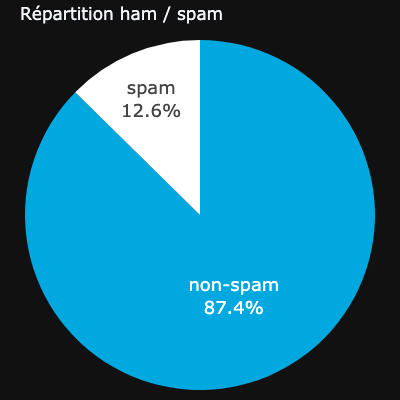

In [111]:
spam_count = df["spam"].value_counts().rename(MAP_SPAM)
NB_SPAMS = spam_count.loc["spam"]
NB_HAMS = spam_count.loc["ham"]
NB_MESSAGES = NB_SPAMS + NB_HAMS

print(
    "Répartition des messages :\n" +
    spam_count.to_string(header=False) + "\n"
)

fig = px.pie(
    names=df["spam"].map(MAP_SPAM_FR),
    title="Répartition ham / spam",
    color=df["spam"].map(MAP_SPAM_FR),
    color_discrete_map=COLOR_MAP_STR_FR
)
fig.update_traces(
    textinfo="label+percent",
    textposition="inside",
    textfont=dict(size=18),
)
fig.update_layout(
    showlegend=False,
    width=400,
    height=400,
    margin=dict(t=40, b=10, l=10, r=10)  # réduire les marges pour augmenter la taille du camembert
)
fig_name = "Repartition ham spam"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Nous sommes clairement dans un cas de **déséquilibre de classe** dont il faudra tenir compte pour la séparation des données pour les jeux d'entraînement, de validation et de test.

### 2.2 Marqueurs de spam

Parmi les indicateurs les plus immédiats à repérer pouvant indiquer si un message est un spam, nous avons :
- la longueur du message,
- la présence de mots à forte charge commerciale ou incitative ("free", "win", "prize", etc.),
- une notion d'urgence ou d'action impérative,
- une utilisation excessive de la ponctuation ("!!!"),
- la présence d'une somme d'argent,
- la présence d'un lien URL,
- une part importante de mots écrits en majuscules.

Nous analysons ci-après leurs influences respectives.

#### 2.2.1 Longueur du message

Statistiques :
         Longueur du SMS [nb. de caractères]                                  Nombre de mots                              
                                       count mean std min  25%  50%  75%  max          count mean std min 25% 50% 75%  max
spam                                                                                                                      
non-spam                                4516   74  56   5   37   56   95  913           4516   14  11   1   7  11  19  171
spam                                     653  141  29  16  135  152  160  227            653   23   5   2  22  25  28   35



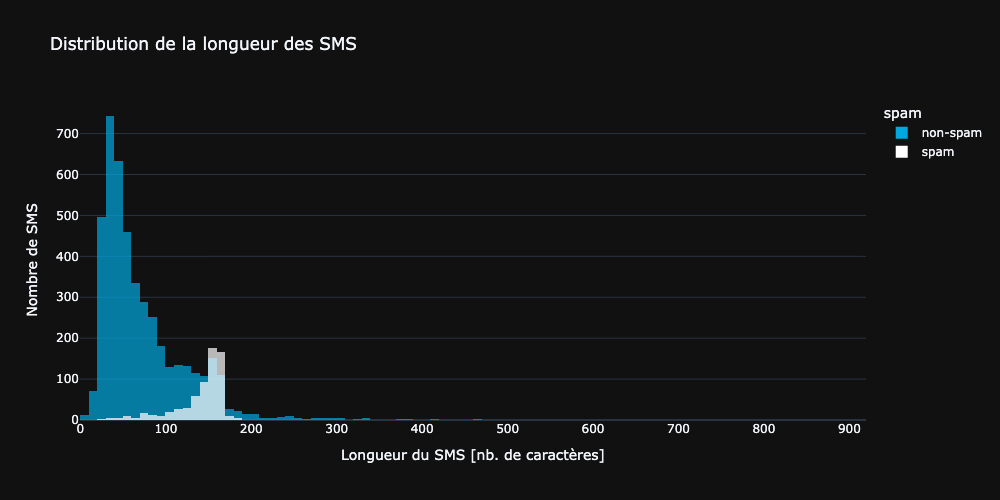

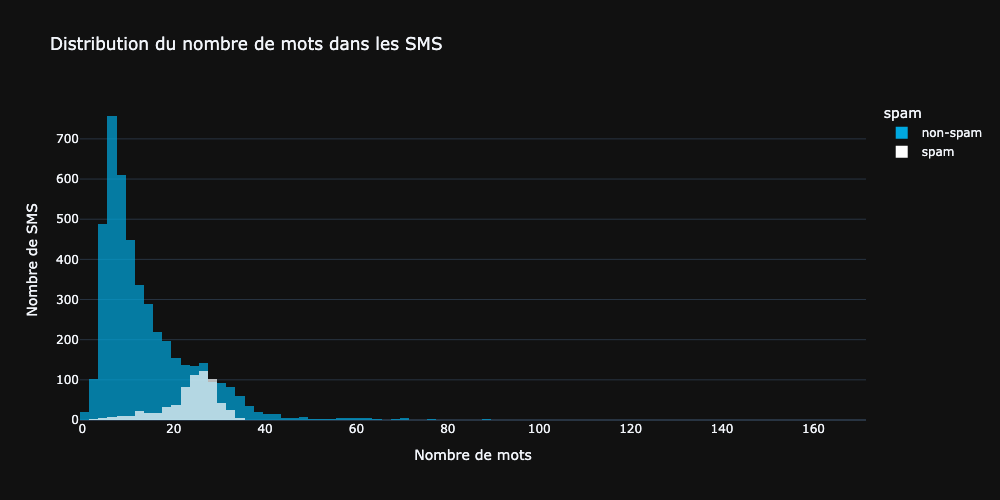

In [112]:
len_str = "Longueur du SMS [nb. de caractères]"
nb_str = "Nombre de mots"

spam_indicators = df.copy()
spam_indicators[len_str] = spam_indicators["sms"].str.len()
spam_indicators[nb_str] = spam_indicators["sms"].str.split().str.len()
spam_indicators.replace({"spam": MAP_SPAM_FR}, inplace=True)

print(
    "Statistiques :\n" +
    spam_indicators.groupby("spam").describe(exclude=[str]).astype(int).to_string() + "\n"
)

fig = px.histogram(
    spam_indicators,
    x=len_str,
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    barmode="overlay",
    opacity=0.7,
    nbins=100,
    title="Distribution de la longueur des SMS"
)
fig.update_yaxes(title="Nombre de SMS")
fig_name = "Distribution longueur SMS"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

fig = px.histogram(
    spam_indicators,
    x=nb_str,
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    barmode="overlay",
    opacity=0.7,
    nbins=100,
    title="Distribution du nombre de mots dans les SMS"
)
fig.update_yaxes(title="Nombre de SMS")
fig_name = "Distribution nombre mots SMS"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

del spam_indicators

Nous remarquons que les messages non-spam sont plus courts en longueur comme en nombre de mots que les spams.
Pour les non-spams, les moyennes sont de 74 caractères et 14 mots, alors que pour les spams, elles passent à 141 caractères et 23 mots.
Le ratio est par conséquent d'environ 2 entre les deux classes.
Il grimpe entre 2,5 et 3 pour les médianes (56 vs 152 caractères, 11 vs 25 mots).

Sur les histogrammes, nous constatons une forte chute des effectifs à environ 160 caractères.
Cette valeur correspond à la limite de la taille maximale d'un SMS.

#### 2.2.2 Présence de mots à forte charge commerciale ou incitative

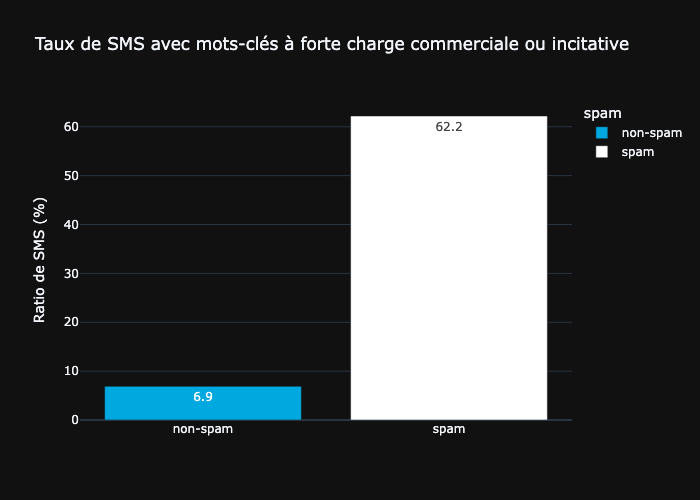

In [139]:
bait = df.copy()
patterns = r'free|win|won|prize|reward|cash|claim|congrat|guarant|offer'
patterns += '|bonus|gift|voucher|cash|money|credit|jackpot|award|lottery'
patterns += '|lucky|selected|entitled|complimentary'
bait['has_bait'] = bait['sms'].str.contains(patterns, regex=True, case=False).astype(int)
bait_count = (
    bait
    .groupby("spam")
    .agg({"has_bait": "sum"})
    .rename(MAP_SPAM)
    ["has_bait"]
    .div(spam_count)
    .mul(100)
    .round(1)
    .rename("Ratio de SMS")
    .reset_index()
    .replace({"spam": MAP_SPAM_INV})
    .replace({"spam": MAP_SPAM_FR})
)

fig = px.bar(
    bait_count,
    x="spam",
    y="Ratio de SMS",
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    text_auto=True,
    title="Taux de SMS avec mots-clés à forte charge commerciale ou incitative"
)
fig.update_xaxes(title="")
fig.update_yaxes(title="Ratio de SMS (%)")
fig.update_layout(
    width=700
)
fig_name = "taux SMS avec mots cles charge commerciale"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

del bait

Les spams contiennent clairement plus de mots-clés à caractère commercial ou incitatif (~62%) que les hams (~7%).

#### 2.2.3 Notion d'urgence ou d'action impérative

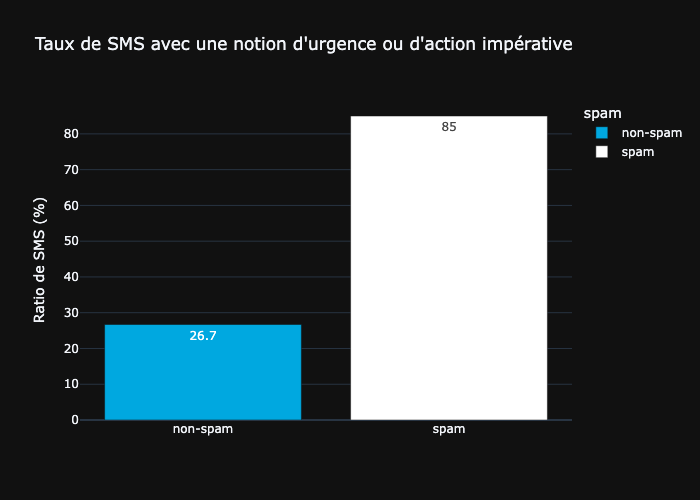

In [113]:
urgence = df.copy()
patterns = r'call|text|reply|click|visit|subscribe|register|apply|confirm|activate'
patterns += '|redeem|claim|collect|download|join|start|stop'
patterns += '|urgent|now|today|immediat|hurry|quick|last|final|expire|deadline'
patterns += '|limited|only|ends|closing'
urgence['has_urgence'] = urgence['sms'].str.contains(patterns, regex=True, case=False).astype(int)
urgence_count = (
    urgence
    .groupby("spam")
    .agg({"has_urgence": "sum"})
    .rename(MAP_SPAM)
    ["has_urgence"]
    .div(spam_count)
    .mul(100)
    .round(1)
    .rename("Ratio de SMS")
    .reset_index()
    .replace({"spam": MAP_SPAM_INV})
    .replace({"spam": MAP_SPAM_FR})
)

fig = px.bar(
    urgence_count,
    x="spam",
    y="Ratio de SMS",
    text_auto=True,
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    title="Taux de SMS avec une notion d'urgence ou d'action impérative"
)
fig.update_xaxes(title="")
fig.update_yaxes(title="Ratio de SMS (%)")
fig.update_layout(
    width=700
)
fig_name = "taux SMS notion urgence"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

del urgence

Presque tous les spams contiennent une notion d'urgence ou d'action impérative (85%).
Cependant, une part non négligeable des hams (~27%) en contient aussi.

#### 2.2.4 Usage excessif de la ponctuation

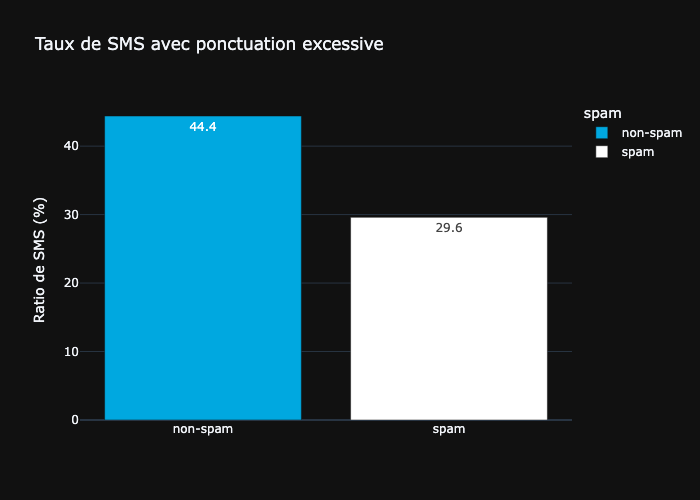

In [114]:
punctuation = df.copy()
# Recherche en REGEX de :
# - 2+ points d'exclamation,
# - 2+ points d'interrogation,
# - "?!", "!?", "?!?!", ...,
# - 4+ points (points de suspension étendus)
patterns = r'!{2,}|\?{2,}|[!?]{2,}|\.{4,}'
punctuation['has_punctuation'] = punctuation['sms'].str.contains(patterns, regex=True, case=False).astype(int)
# On ajoute les ratios élevés de symboles de ponctuation (relativement au nombre de caractères) :
patterns = f"[{re.escape(string.punctuation)}]"  # tous les caractères avec échappement pour regex
punctuation['has_punctuation'] = (
        punctuation['has_punctuation'] |
        (punctuation['sms'].str.count(patterns) / punctuation['sms'].str.len() > 0.05)
)
punctuation_count = (
    punctuation
    .groupby("spam")
    .agg({"has_punctuation": "sum"})
    .rename(MAP_SPAM)
    ["has_punctuation"]
    .div(spam_count)
    .mul(100)
    .round(1)
    .rename("Ratio de SMS")
    .reset_index()
    .replace({"spam": MAP_SPAM_INV})
    .replace({"spam": MAP_SPAM_FR})
)

fig = px.bar(
    punctuation_count,
    x="spam",
    y="Ratio de SMS",
    text_auto=True,
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    title="Taux de SMS avec ponctuation excessive"
)
fig.update_xaxes(title="")
fig.update_yaxes(title="Ratio de SMS (%)")
fig.update_layout(
    width=700
)
fig_name = "taux SMS avec ponctuation excessive"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

del punctuation

Prise isolément, la ponctuation ne semble pas être un marqueur discriminant pour la détection de spam.
Il faudrait certainement la combiner à d'autres marqueurs pour démontrer qu'elle a un effet.

#### 2.2.5 Présence d'une somme d'argent

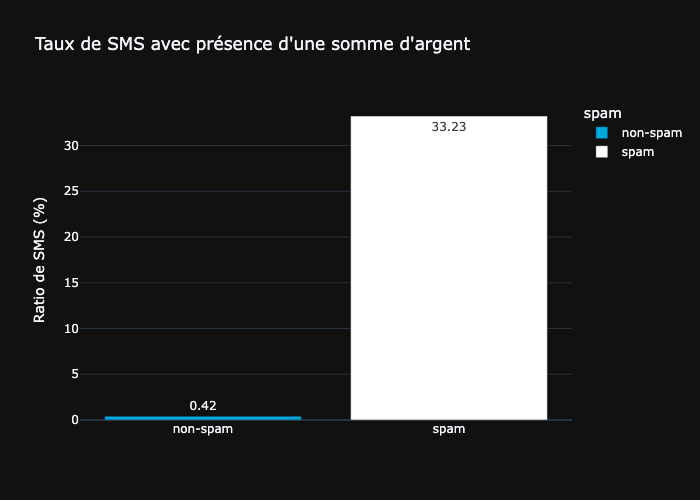

In [117]:
money = df.copy()
money['has_money'] = money['sms'].str.contains(r'[$€£]', regex=True, case=False).astype(int)
money_count = (
    money
    .groupby("spam")
    .agg({"has_money": "sum"})
    .rename(MAP_SPAM)
    ["has_money"]
    .div(spam_count)
    .mul(100)
    .round(2)
    .rename("Ratio de SMS")
    .reset_index()
    .replace({"spam": MAP_SPAM_INV})
    .replace({"spam": MAP_SPAM_FR})
)

fig = px.bar(
    money_count,
    x="spam",
    y="Ratio de SMS",
    text_auto=True,
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    title="Taux de SMS avec présence d'une somme d'argent"
)
fig.update_xaxes(title="")
fig.update_yaxes(title="Ratio de SMS (%)")
fig.update_layout(
    width=700
)
fig_name = "taux SMS somme argent"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

del money

Le constat est clair : un tiers des spams contiennent une somme d'argent alors que moins d'un pour cent (0,42%) des non-spams en ont.

#### 2.2.6 Présence d'un lien URL

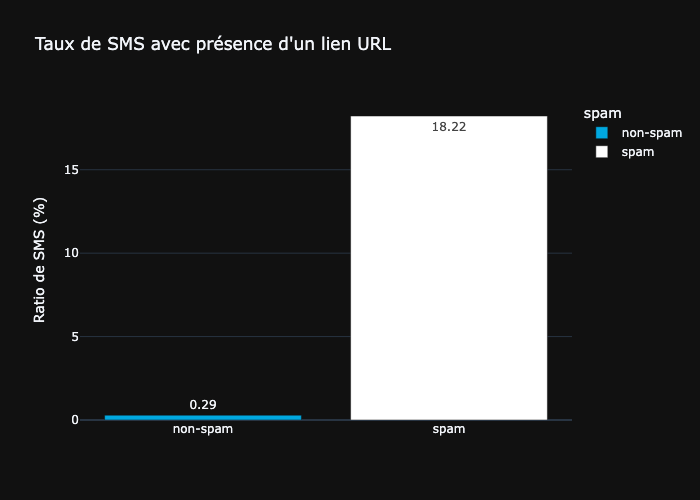

In [125]:
url_link = df.copy()
url_link['has_url'] = url_link['sms'].str.contains(r"http|www\.|\.com|\.co\.uk|\.net|\.org", regex=True, case=False).astype(int)
url_link_count = (
    url_link
    .groupby("spam")
    .agg({"has_url": "sum"})
    .rename(MAP_SPAM)
    ["has_url"]
    .div(spam_count)
    .mul(100)
    .round(2)
    .rename("Ratio de SMS")
    .reset_index()
    .replace({"spam": MAP_SPAM_INV})
    .replace({"spam": MAP_SPAM_FR})
)

fig = px.bar(
    url_link_count,
    x="spam",
    y="Ratio de SMS",
    text_auto=True,
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    title="Taux de SMS avec présence d'un lien URL"
)
fig.update_xaxes(title="")
fig.update_yaxes(title="Ratio de SMS (%)")
fig.update_layout(
    width=700
)
fig_name = "taux SMS lien URL"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

del url_link

Près d'un spam sur cinq (~18%) contient au moins un lien URL, alors que les non-spams n'en contiennent quasiment pas (seuls 0,29% des non-spams).

#### 2.2.7 Présence d'un trop grand nombre de majuscules

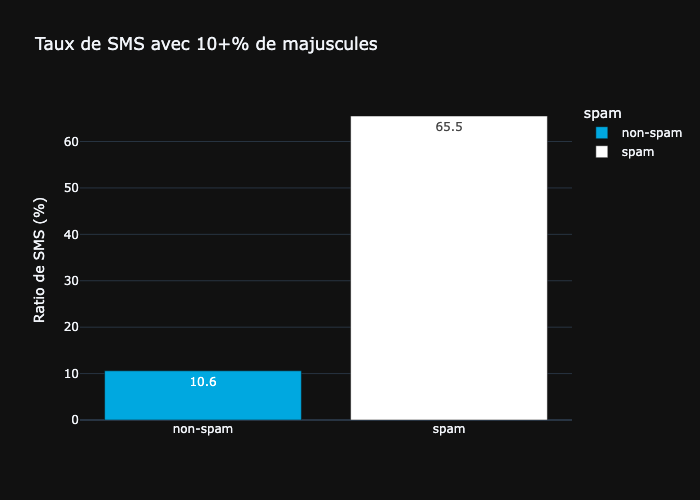

In [128]:
uppercase = df.copy()
# ratio arbitraire de 10%
uppercase['has_uppercase'] = uppercase['sms'].str.count(r"[A-Z]") / uppercase['sms'].str.count(r"[A-Za-z]") > 0.1
uppercase_count = (
    uppercase
    .groupby("spam")
    .agg({"has_uppercase": "sum"})
    .rename(MAP_SPAM)
    ["has_uppercase"]
    .div(spam_count)
    .mul(100)
    .round(1)
    .rename("Ratio de SMS")
    .reset_index()
    .replace({"spam": MAP_SPAM_INV})
    .replace({"spam": MAP_SPAM_FR})
)

fig = px.bar(
    uppercase_count,
    x="spam",
    y="Ratio de SMS",
    text_auto=True,
    color="spam",
    color_discrete_map=COLOR_MAP_STR_FR,
    title="Taux de SMS avec 10+% de majuscules"
)
fig.update_xaxes(title="")
fig.update_yaxes(title="Ratio de SMS (%)")
fig.update_layout(
    width=700
)
fig_name = "taux SMS avec trop majuscules"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

del uppercase

Près des deux tiers des spams (65,5%) contiennent au moins 10% de caractères en majuscule. Seulement 10,6% des non-spams contiennent ce même ratio.

### 2.3 Bilan de l'EDA

Le jeu de données présente un fort **déséquilibre de classe**, à corriger lors du split train/test/val, avec :
- 87,4% de non-spams,
- 12,6% de spams.

Synthèse des marqueurs étudiés, triés par pouvoir discriminant décroissant :

| Marqueur                  | Spams               | Non-spams          | Discriminant       |
|---------------------------|---------------------|--------------------|--------------------|
| Somme d'argent ($, €, £)  | 33%                 | 0,4%               | très fort          |
| Lien URL                  | 18%                 | 0,3%               | très fort          |
| Mots à charge commerciale | 62%                 | 7%                 | fort               |
| Ratio de majuscules > 10% | 65,5%               | 10,6%              | fort               |
| Longueur du SMS           | ~141 car. / 23 mots | ~74 car. / 14 mots | fort               |
| Notion d'urgence          | 85%                 | 27%                | modéré             |
| Ponctuation excessive     | similaire           | similaire          | faible (isolément) |

**Conclusion** : les SMS spam se distinguent nettement par la mention de sommes d'argent, la présence d'URL, un vocabulaire commercial et un usage marqué des majuscules. La longueur et l'urgence renforcent le signal sans suffire seules. Ces régularités lexicales et structurelles confirment qu'un modèle exploitant la sémantique du texte (embeddings, transformer pré-entraîné) devrait capturer efficacement ces motifs sans qu'il soit nécessaire de les expliciter en attributs manuels.

---

## Partie 3 - Préparation des données pour le deep learning

Avant d'entraîner les modèles, les données brutes doivent être transformées en tenseurs adaptés à PyTorch. Cette partie sépare les données en jeux d'entraînement, de validation et de test, applique la tokenisation, construit les `Dataset` et `DataLoader` PyTorch, et met en place le mécanisme de gestion du déséquilibre de classe identifié à l'EDA.

### 3.1 Séparation train / validation / test

In [21]:
# Séparation stratifiée en 60% train / 20% validation / 20% test
# La stratification est essentielle vu le déséquilibre de classe (87,4% ham / 12,6% spam)

X = df["sms"].to_numpy()
y = df["spam"].to_numpy(dtype=np.int64)

# Premier découpage : on isole le jeu de test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Deuxième découpage : on sépare train et validation à partir de la portion restante
# Le ratio est ajusté pour obtenir 20% de validation sur le total initial
val_ratio = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_ratio,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

# Vérification des tailles et de la conservation du ratio spam/ham
split_summary = pd.DataFrame(
    {
        "Effectif": [len(y_train), len(y_val), len(y_test)],
        "Ratio spam (%)": [
            round(y_train.mean() * 100, 2),
            round(y_val.mean() * 100, 2),
            round(y_test.mean() * 100, 2),
        ],
    },
    index=["train", "validation", "test"]
)
print(split_summary.to_string())


            Effectif  Ratio spam (%)
train           3101           12.61
validation      1034           12.67
test            1034           12.67


### 3.2 Tokenisation

Pour les modèles construits de zéro (partie 4), nous utilisons le tokenizer `cl100k_base` (celui de GPT-4).
Pour DistilBERT (partie 5), le tokenizer associé au modèle pré-entraîné sera utilisé directement.

Ce choix repose sur deux propriétés du tokenizer BPE de GPT-4. D'une part, son découpage en sous-mots élimine quasi totalement le risque de token hors-vocabulaire : un mot inédit en validation ou en test est segmenté en sous-mots fréquents qui, eux, ont presque toujours été vus à l'entraînement. D'autre part, réutiliser un tokenizer pré-entraîné évite d'avoir à construire et calibrer un vocabulaire dédié au corpus, étape d'ingénierie supplémentaire pour un gain marginal sur des SMS aussi courts.

La contrepartie est connue et assumée : la table d'embedding est largement surdimensionnée par rapport au vocabulaire effectivement présent dans le corpus. Les lignes inutilisées ne reçoivent aucun gradient et restent à leur initialisation. C'est un surcoût mémoire, sans incidence sur l'entraînement ni sur la généralisation.

In [22]:
# Tokenizer cl100k_base : sous-mots BPE (Byte Pair Encoding), vocabulaire de ~100k tokens
tiktoken_tokenizer = tiktoken.get_encoding("cl100k_base")
VOCAB_SIZE = tiktoken_tokenizer.n_vocab


def encode_texts(texts):
    """Encode a list of strings into a list of token id lists."""
    return [tiktoken_tokenizer.encode(text) for text in texts]


train_tokens = encode_texts(X_train)
val_tokens = encode_texts(X_val)
test_tokens = encode_texts(X_test)

print(f"Taille du vocabulaire : {VOCAB_SIZE}")
print(f"Exemple de tokens (premier SMS train) : {train_tokens[0][:15]}...")

Taille du vocabulaire : 100277
Exemple de tokens (premier SMS train) : [1688, 279, 32079, 2162, 449, 91149, 323, 18233, 262]...


In [23]:
train_lengths = np.array([len(t) for t in train_tokens])
print(
    f"Longueurs en tokens (train) :\n"
    f"\tmin    = {train_lengths.min()}\n"
    f"\tmean   = {train_lengths.mean():.1f}\n"
    f"\tmedian = {int(np.median(train_lengths))}\n"
    f"\tp95    = {int(np.percentile(train_lengths, 95))}\n"
    f"\tmax    = {train_lengths.max()}"
)
coverage = (train_lengths <= MAX_SEQ_LEN).mean() * 100
print(f"\nMAX_SEQ_LEN = {MAX_SEQ_LEN} -> couvre {coverage:.1f}% des SMS sans troncature")

Longueurs en tokens (train) :
	min    = 2
	mean   = 23.0
	median = 17
	p95    = 52
	max    = 260

MAX_SEQ_LEN = 64 -> couvre 98.8% des SMS sans troncature


La distribution des longueurs en tokens (médiane à 17, p95 à 52, max à 260) confirme que les SMS sont courts. La valeur `MAX_SEQ_LEN = 64` retenue couvre 98,8% des messages sans troncature, avec une marge de 23% au-dessus du p95. La perte d'information sur les ~1,2% restants reste très limitée car les marqueurs discriminants identifiés lors de l'EDA (sommes d'argent, vocabulaire commercial, actions impératives, etc.) apparaissent généralement en début de message.

### 3.3 Datasets et DataLoaders PyTorch

In [24]:
# def pad_sequences(sequences, max_length=MAX_SEQ_LEN):
#     """Truncate or right-pad token sequences to a fixed length using 0 as padding id."""
#     return [seq[:max_length] + [0] * max(0, max_length - len(seq)) for seq in sequences]

# Correction : il ne faut pas utiliser le padding avec l'id 0, car c'est celui de "!"
def pad_sequences(sequences, max_length=MAX_SEQ_LEN, pad_value=VOCAB_SIZE):
    """Truncate or right-pad token sequences to a fixed length."""
    return [seq[:max_length] + [pad_value] * max(0, max_length - len(seq)) for seq in sequences]


class SMSDataset(Dataset):
    """Tensor dataset wrapping tokenized SMS messages and their binary labels."""

    def __init__(self, tokens, labels):
        padded = pad_sequences(tokens)
        self.tokens = torch.tensor(padded, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tokens[idx], self.labels[idx]


# Construction des datasets
train_dataset = SMSDataset(train_tokens, y_train)
val_dataset = SMSDataset(val_tokens, y_val)
test_dataset = SMSDataset(test_tokens, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Vérification de la forme d'un batch
sample_x, sample_y = next(iter(train_loader))
print(f"Shape d'un batch d'entrée  : {tuple(sample_x.shape)}")
print(f"Shape d'un batch de labels : {tuple(sample_y.shape)}")

Shape d'un batch d'entrée  : (32, 64)
Shape d'un batch de labels : (32,)


### 3.4 Gestion du déséquilibre de classe pour les modèles construits de zéro

Pour les trois modèles construits de zéro (partie 4), plutôt que de sur-échantillonner les spams (risque de surapprentissage sur le petit jeu de données) ou de sous-échantillonner les non-spams (perte d'information), nous utilisons l'argument `pos_weight` de `BCEWithLogitsLoss`. Cela pondère le coût des exemples positifs (spams) dans la fonction de coût, sans modifier la distribution des données. Le périmètre de cette stratégie est limité à la partie 4 : le choix méthodologique retenu pour le fine-tuning de DistilBERT en partie 5 est différent et justifié en tête de cette partie.

In [25]:
# pos_weight = nombre de négatifs / nombre de positifs sur le jeu d'entraînement
# On ne touche jamais aux jeux de validation et de test
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
print(f"Nb non-spams (train) : {n_neg}")
print(f"Nb spams (train)     : {n_pos}")
print(f"pos_weight           : {pos_weight.item():.3f}")

Nb non-spams (train) : 2710
Nb spams (train)     : 391
pos_weight           : 6.931


---

## Partie 4 - Modèles construits de zéro

Cette partie construit trois architectures de complexité croissante, chacune représentative d'une famille de réseaux de neurones :

- **Modèle 1 (baseline)** : architecture *feed-forward* minimaliste, qui ignore l'ordre des mots.
- **Modèle 2 (TextCNN)** : réseau convolutif 1D capturant les motifs locaux (n-grammes).
- **Modèle 3 (BiLSTM)** : réseau récurrent bidirectionnel modélisant les dépendances séquentielles.

Tous trois partagent la même boucle d'entraînement, les mêmes données et la même fonction de coût, ce qui permet une comparaison équitable. L'objectif est double : disposer d'un plancher de performance solide et identifier laquelle de ces familles est la mieux adaptée à la nature du signal présent dans les SMS.

### 4.1 Fonctions communes d'entraînement et d'évaluation

Pour les trois modèles construits de zéro, nous utilisons la même boucle d'entraînement, la même fonction d'évaluation et les mêmes utilitaires de visualisation. La fonction de coût retenue est `BCEWithLogitsLoss` (entropie croisée binaire avec sigmoïde fusionnée, plus stable numériquement) pondérée par `pos_weight` pour gérer le déséquilibre.

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run a single training epoch and return mean loss and binary F1."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs).squeeze(-1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)  # on "dé-moyenne" : on récupère la somme du batch
        preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.long().cpu().numpy().tolist())
    avg_loss = total_loss / len(loader.dataset)  # on divise par le nombre total d'exemples
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, f1


def evaluate_model(model, loader, criterion, device):
    """Evaluate the model and return loss, F1, labels, predictions and probabilities."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs).squeeze(-1)
            loss = criterion(logits, labels)
            total_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.long().cpu().numpy().tolist())
    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    save_path=None,
    verbose=True,
):
    """Train a model with early stopping on validation F1, save it, and reload best state."""
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _, _ = evaluate_model(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if verbose:
            print(
                f"Epoch {epoch:2d}/{epochs} | "
                f"train loss={train_loss:.4f} F1={train_f1:.4f} | "
                f"val loss={val_loss:.4f} F1={val_f1:.4f}"
            )

        # Early stopping basé sur le F1 de validation
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            epochs_no_improve = 0
            if save_path is not None:
                torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(
                        f"Early stopping à l'epoch {epoch} "
                        f"(meilleur F1 val = {best_val_f1:.4f} à l'epoch {best_epoch})"
                    )
                break

    # Rechargement du meilleur état pour les évaluations ultérieures
    if save_path is not None and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))
    return model, history

In [27]:
def plot_training_history(history, model_name):
    """Plot the train/val loss and F1 curves for a single model."""
    epochs_range = list(range(1, len(history["train_loss"]) + 1))
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f"Loss - {model_name}", f"F1 (spam) - {model_name}"),
    )
    # Loss
    fig.add_trace(
        go.Scatter(x=epochs_range, y=history["train_loss"], name="train",
                   mode="lines+markers", line=dict(color=DEFAULT_COLOR)),
        row=1, col=1,
    )
    fig.add_trace(
        go.Scatter(x=epochs_range, y=history["val_loss"], name="validation",
                   mode="lines+markers", line=dict(color=ALT_COLOR)),
        row=1, col=1,
    )
    # F1
    fig.add_trace(
        go.Scatter(x=epochs_range, y=history["train_f1"], name="train",
                   mode="lines+markers", line=dict(color=DEFAULT_COLOR), showlegend=False),
        row=1, col=2,
    )
    fig.add_trace(
        go.Scatter(x=epochs_range, y=history["val_f1"], name="validation",
                   mode="lines+markers", line=dict(color=ALT_COLOR), showlegend=False),
        row=1, col=2,
    )
    fig.update_xaxes(title="Epoch")
    fig.update_layout(height=400, width=1000, title_text=f"Courbes d'entraînement : {model_name}")
    return fig


def plot_confusion_matrix(y_true, y_pred, model_name, set_name="test"):
    """Plot the confusion matrix as a Plotly heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    labels = ["non-spam", "spam"]
    z_text = [[str(v) for v in row] for row in cm]
    fig = px.imshow(
        cm,
        x=labels,
        y=labels,
        color_continuous_scale="Blues",
        text_auto=True,
        labels=dict(x="Prédiction", y="Réalité", color="Nombre"),
        title=f"Matrice de confusion - {model_name} ({set_name})",
    )
    fig.update_layout(width=500, height=450)
    return fig

### 4.2 Modèle 1 - Embedding moyenné (baseline)

Architecture minimaliste : une couche `Embedding` apprise sur les données, suivie d'un pooling moyen global sur les tokens (chaque SMS est résumé par la moyenne des vecteurs de ses tokens), puis d'une couche linéaire de sortie. Le modèle ignore totalement l'ordre des mots, mais sert de plancher de comparaison solide.

Par convention en NLP, on parle de "dimension temporelle" pour désigner la dimension qui indexe la position des tokens dans la séquence. Ce vocabulaire est hérité des architectures récurrentes (RNN, LSTM) qui traitent les tokens séquentiellement, mais il s'est généralisé à tous les modèles manipulant des séquences. Dans la suite, "pooling sur la dimension temporelle" signifiera donc "pooling sur les tokens".

In [28]:
class BaselineClassifier(nn.Module):
    """Embedding + average pooling + linear head for binary classification."""

    def __init__(self, vocab_size, embed_dim=EMBED_DIM):
        super().__init__()
        # self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=vocab_size)  # correction padding
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len) -> (batch, seq_len, embed_dim)
        emb = self.embedding(x)
        # On permute pour appliquer le pooling sur la dimension temporelle
        emb = emb.permute(0, 2, 1)  # (batch, embed_dim, seq_len)
        pooled = self.pool(emb).squeeze(-1)  # (batch, embed_dim)
        return self.fc(pooled)  # logits (batch, 1)

In [29]:
# Initialisation, fonction de coût et optimiseur
set_seed(RANDOM_STATE)
baseline_model = BaselineClassifier(vocab_size=VOCAB_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)

# Comptage des paramètres entraînables
n_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(baseline_model)
print(f"\nNombre de paramètres entraînables : {n_params:,}")


BaselineClassifier(
  (embedding): Embedding(100278, 64, padding_idx=100277)
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Nombre de paramètres entraînables : 6,417,857


In [30]:
# Entraînement de la baseline avec early stopping
baseline_model, baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    save_path=os.path.join(MODELS_DIR, "baseline.pt"),
)

Epoch  1/50 | train loss=1.1428 F1=0.4639 | val loss=1.0693 F1=0.6768
Epoch  2/50 | train loss=0.9222 F1=0.7676 | val loss=0.8455 F1=0.6964
Epoch  3/50 | train loss=0.6832 F1=0.8166 | val loss=0.6734 F1=0.7462
Epoch  4/50 | train loss=0.5136 F1=0.8460 | val loss=0.5503 F1=0.7970
Epoch  5/50 | train loss=0.4026 F1=0.8691 | val loss=0.4680 F1=0.8148
Epoch  6/50 | train loss=0.3290 F1=0.8928 | val loss=0.4123 F1=0.8315
Epoch  7/50 | train loss=0.2761 F1=0.9123 | val loss=0.3758 F1=0.8377
Epoch  8/50 | train loss=0.2362 F1=0.9291 | val loss=0.3430 F1=0.8604
Epoch  9/50 | train loss=0.2037 F1=0.9364 | val loss=0.3143 F1=0.8812
Epoch 10/50 | train loss=0.1777 F1=0.9427 | val loss=0.2951 F1=0.8846
Epoch 11/50 | train loss=0.1568 F1=0.9519 | val loss=0.2772 F1=0.9008
Epoch 12/50 | train loss=0.1386 F1=0.9569 | val loss=0.2734 F1=0.8992
Epoch 13/50 | train loss=0.1233 F1=0.9605 | val loss=0.2562 F1=0.9042
Epoch 14/50 | train loss=0.1101 F1=0.9617 | val loss=0.2492 F1=0.9035
Epoch 15/50 | train 

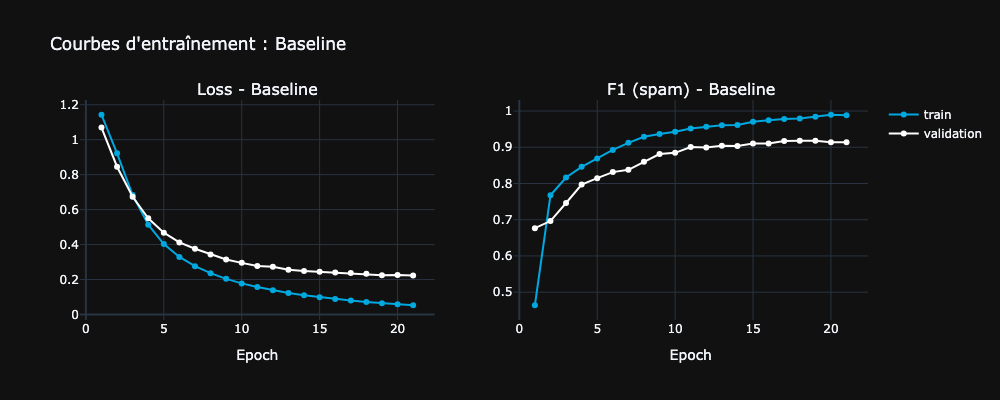

In [131]:
fig = plot_training_history(baseline_history, "Baseline")
index_image = export_figure_to_png(fig, idx_img=index_image, name="baseline_history")
show_figure(fig)

**Lecture de l'entraînement.** L'early stopping s'est déclenché à l'epoch 21, le meilleur état correspondant à l'epoch 18 avec un F1 de validation de 0,9183. La `val_loss` décroît de manière quasi-monotone tout au long de l'entraînement (de 1,07 à 0,22), tandis que le F1 de validation plafonne autour de l'epoch 18 puis décroche très légèrement, ce qui déclenche l'arrêt anticipé sur cette métrique. L'écart entre `train_loss` et `val_loss` au meilleur état reste contenu (~0,16) sans divergence, signe d'un entraînement sain et sans surapprentissage marqué.

**Performance obtenue.** Un F1 supérieur à 0,91 pour une architecture aussi simple est un résultat fort. Le modèle agrège l'information en moyennant les vecteurs des tokens, sans tenir compte de leur ordre. Cela suggère que les signaux discriminants identifiés lors de l'EDA (sommes d'argent, URL, vocabulaire commercial, majuscules) sont avant tout des **occurrences lexicales** dont la simple présence suffit largement à orienter la classification, indépendamment de la syntaxe.

Cette baseline solide fixe une référence exigeante pour les architectures plus complexes étudiées dans les sections suivantes.

### 4.3 Modèle 2 - TextCNN (réseau convolutif 1D)

Architecture de Yoon Kim (2014) appliquée aux SMS. On utilise plusieurs noyaux de convolution de tailles différentes (3, 4, 5) pour capturer des n-grammes de longueurs variées (motifs comme `"win prize"`, `"call now"`, `"free entry to"`), puis un max-pooling global pour ne garder que le signal le plus fort par filtre. Particulièrement adapté aux signaux locaux mis en évidence par l'EDA.

Kim, Y. (2014). *Convolutional Neural Networks for Sentence Classification*. EMNLP 2014, pp. 1746-1751. [aclanthology.org/D14-1181](https://aclanthology.org/D14-1181/)

In [32]:
class TextCNN(nn.Module):
    """Multi-kernel 1D convolutional network for text classification (Kim, 2014)."""

    def __init__(
        self,
        vocab_size,
        embed_dim=EMBED_DIM,
        kernel_sizes=(3, 4, 5),
        num_filters=64,
        dropout=0.5,
    ):
        super().__init__()
        # self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=vocab_size)  # correction padding
        # Une convolution par taille de noyau, padding pour conserver la longueur
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)  # (batch, embed_dim, seq_len)
        # Convolution + ReLU + max-pooling global sur la dimension temporelle
        conv_outs = [F.relu(conv(emb)).max(dim=-1)[0] for conv in self.convs]
        concat = torch.cat(conv_outs, dim=1)  # (batch, num_filters * n_kernels)
        return self.fc(self.dropout(concat))

In [33]:
# Initialisation
set_seed(RANDOM_STATE)
textcnn_model = TextCNN(vocab_size=VOCAB_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.Adam(textcnn_model.parameters(), lr=LEARNING_RATE)

n_params = sum(p.numel() for p in textcnn_model.parameters() if p.requires_grad)
print(textcnn_model)
print(f"\nNombre de paramètres entraînables : {n_params:,}")

TextCNN(
  (embedding): Embedding(100278, 64, padding_idx=100277)
  (convs): ModuleList(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(2,))
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=192, out_features=1, bias=True)
)

Nombre de paramètres entraînables : 6,467,329


In [34]:
# Entraînement
textcnn_model, textcnn_history = train_model(
    textcnn_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    save_path=os.path.join(MODELS_DIR, "textcnn.pt"),
)

Epoch  1/50 | train loss=0.8675 F1=0.4166 | val loss=0.5146 F1=0.6994
Epoch  2/50 | train loss=0.3919 F1=0.7275 | val loss=0.3798 F1=0.7930
Epoch  3/50 | train loss=0.2393 F1=0.8217 | val loss=0.3283 F1=0.8175
Epoch  4/50 | train loss=0.1715 F1=0.8858 | val loss=0.3097 F1=0.8506
Epoch  5/50 | train loss=0.1276 F1=0.9225 | val loss=0.2589 F1=0.8215
Epoch  6/50 | train loss=0.0791 F1=0.9521 | val loss=0.2788 F1=0.8657
Epoch  7/50 | train loss=0.0497 F1=0.9749 | val loss=0.3199 F1=0.8872
Epoch  8/50 | train loss=0.0496 F1=0.9749 | val loss=0.3304 F1=0.9055
Epoch  9/50 | train loss=0.0385 F1=0.9861 | val loss=0.2731 F1=0.8839
Epoch 10/50 | train loss=0.0265 F1=0.9848 | val loss=0.3279 F1=0.8984
Epoch 11/50 | train loss=0.0234 F1=0.9861 | val loss=0.3333 F1=0.8984
Early stopping à l'epoch 11 (meilleur F1 val = 0.9055 à l'epoch 8)


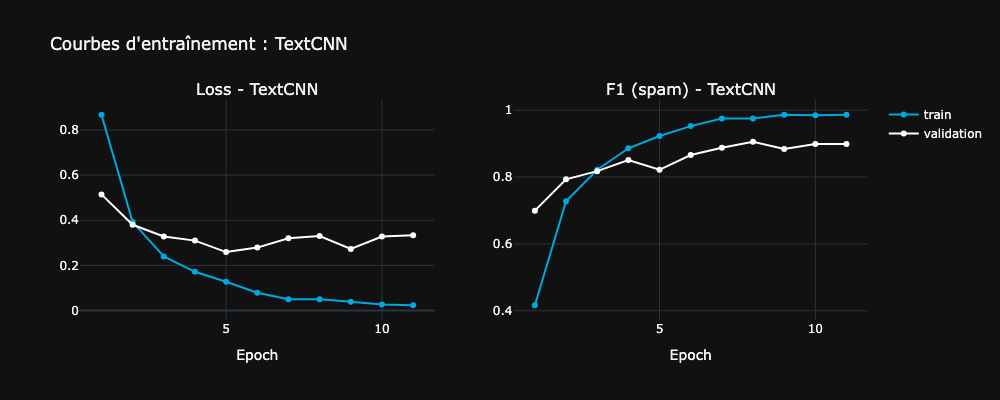

In [132]:
fig = plot_training_history(textcnn_history, "TextCNN")
index_image = export_figure_to_png(fig, idx_img=index_image, name="textcnn_history")
show_figure(fig)

**Lecture de l'entraînement.** L'early stopping s'est déclenché à l'epoch 11, le meilleur état correspondant à l'epoch 8 avec un F1 de validation de 0,9055. La convergence est plus rapide que pour la baseline, mais la `val_loss` cesse de baisser dès l'epoch 5 et se met à osciller, tandis que la `train_loss` continue de descendre. L'écart entre les deux pertes au meilleur état (~0,28) est près de deux fois supérieur à celui observé sur la baseline (~0,16), indiquant un surapprentissage marqué.

**Performance en retrait sur la baseline.** TextCNN obtient un F1 de validation inférieur de 1,3 point à celui du modèle baseline (0,9055 contre 0,9183), malgré une architecture plus expressive avec des convolutions multi-kernels. Ce résultat ne constitue pas un échec mais une information utile : les n-grammes locaux (3 à 5 tokens contigus) que TextCNN cherche à capter ne semblent pas apporter d'information discriminante supplémentaire au-delà de la simple présence des tokens, sur cette tâche. La capacité accrue du modèle se traduit ici par une meilleure mémorisation du jeu d'entraînement, sans gain de généralisation.

### 4.4 Modèle 3 - BiLSTM (réseau récurrent)

Réseau récurrent bidirectionnel : chaque token est traité dans le contexte de tous ceux qui le précèdent et le suivent. On ne conserve ensuite que le max sur la dimension temporelle des états cachés. L'architecture est lente à entraîner mais capte explicitement l'ordre des mots, contrairement à la baseline.

In [36]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM with max-over-time pooling for binary classification."""

    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=64, dropout=0.5):
        super().__init__()
        # self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=vocab_size)  # correction padding
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        # bidirectional => hidden_dim doublé en sortie
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(emb)  # (batch, seq_len, hidden_dim*2)
        # Max-pooling sur la dimension temporelle pour résumer la séquence
        pooled = lstm_out.max(dim=1)[0]  # (batch, hidden_dim*2)
        return self.fc(self.dropout(pooled))

In [43]:
# Initialisation
set_seed(RANDOM_STATE)
bilstm_model = BiLSTMClassifier(vocab_size=VOCAB_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.Adam(bilstm_model.parameters(), lr=LEARNING_RATE)

n_params = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
print(bilstm_model)
print(f"\nNombre de paramètres entraînables : {n_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(100278, 64, padding_idx=100277)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Nombre de paramètres entraînables : 6,484,481


In [44]:
# Entraînement
bilstm_model, bilstm_history = train_model(
    bilstm_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    save_path=os.path.join(MODELS_DIR, "bilstm.pt"),
)

Epoch  1/50 | train loss=0.9800 F1=0.4474 | val loss=0.6641 F1=0.6848
Epoch  2/50 | train loss=0.4231 F1=0.7500 | val loss=0.3435 F1=0.7131
Epoch  3/50 | train loss=0.2935 F1=0.8414 | val loss=0.3622 F1=0.8219
Epoch  4/50 | train loss=0.2196 F1=0.8961 | val loss=0.3146 F1=0.8421
Epoch  5/50 | train loss=0.1357 F1=0.9399 | val loss=0.2810 F1=0.7950
Epoch  6/50 | train loss=0.0901 F1=0.9554 | val loss=0.3302 F1=0.8425
Epoch  7/50 | train loss=0.0756 F1=0.9710 | val loss=0.2721 F1=0.8410
Epoch  8/50 | train loss=0.0486 F1=0.9665 | val loss=0.3098 F1=0.8696
Epoch  9/50 | train loss=0.0347 F1=0.9848 | val loss=0.2842 F1=0.8652
Epoch 10/50 | train loss=0.0210 F1=0.9949 | val loss=0.2777 F1=0.8651
Epoch 11/50 | train loss=0.0165 F1=0.9936 | val loss=0.2836 F1=0.8651
Early stopping à l'epoch 11 (meilleur F1 val = 0.8696 à l'epoch 8)


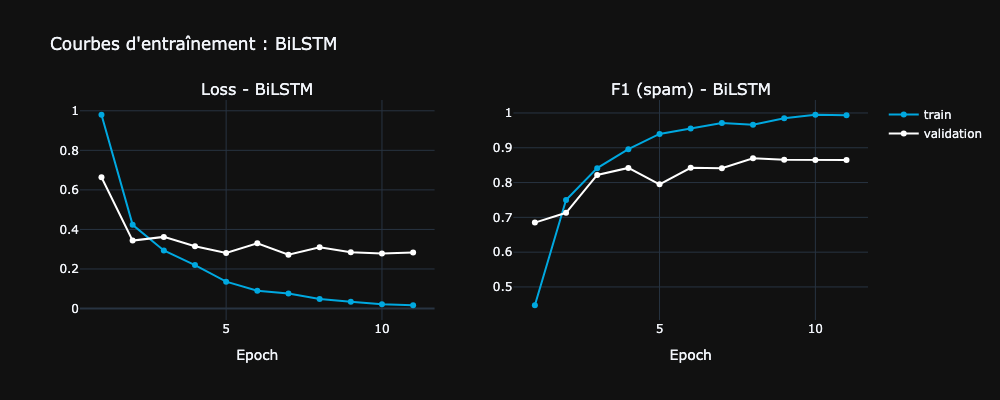

In [133]:
fig = plot_training_history(bilstm_history, "BiLSTM")
index_image = export_figure_to_png(fig, idx_img=index_image, name="bilstm_history")
show_figure(fig)

**Lecture de l'entraînement.** Early stopping à l'epoch 11, meilleur état à l'epoch 8 avec un F1 de validation de 0,8696. Surapprentissage marqué : `train_loss` 0,049 au meilleur état, `val_loss` simultanément à 0,31, F1 d'entraînement atteignant 0,9936 en fin de parcours. L'écart `train_loss` / `val_loss` au meilleur état (~0,26) est près du double de celui de la baseline (~0,16).

**Performance en retrait sur la baseline.** Le BiLSTM perd 4,9 points de F1 de validation par rapport à la baseline (0,8696 contre 0,9183), malgré sa capacité explicite à modéliser les dépendances séquentielles. La capacité accrue ne se traduit pas en gain de généralisation sur ce jeu de données.

**Hiérarchie sur la validation.** Le classement Baseline (0,9183) > TextCNN (0,9055) > BiLSTM (0,8696) place le modèle le plus simple en tête. Cohérent avec un signal essentiellement lexical, où l'ordre des tokens importe peu. La section 4.4.1 quantifie la variance d'exécution du BiLSTM, qui peut nuancer cet écart.

#### 4.4.1 Estimation de la variance entre runs sur device MPS

La note de reproductibilité posée en introduction signale que la passe arrière de `nn.LSTM` n'est pas strictement déterministe sur MPS. BiLSTM est le seul modèle du notebook concerné par cette limitation : les modèles à base de transformer ainsi que la baseline et TextCNN sont reproductibles bit-à-bit dès lors que les graines sont fixées, comme le démontre la section 5.7 pour DistilBERT.

Cette section quantifie empiriquement l'amplitude de cette variance pour BiLSTM. Le protocole est identique à celui de la section 5.7 : on répète à l'identique l'entraînement du modèle 10 fois de suite, avec une graine PyTorch réinitialisée à la même valeur avant chaque run. La seule source d'écart entre runs est donc la non-déterminisme MPS sur les opérations LSTM.

In [45]:
# Nombre de runs pour l'estimation empirique de la variance
N_RUNS_VARIANCE = 100

# Répertoire temporaire pour les checkpoints des runs de variance
bilstm_variance_dir = os.path.join(MODELS_DIR, "bilstm_variance")
os.makedirs(bilstm_variance_dir, exist_ok=True)

bilstm_runs_metrics = []
print(f"Lancement de {N_RUNS_VARIANCE} entraînements BiLSTM à l'identique...\n")

for i in range(N_RUNS_VARIANCE):
    # Reset complet des RNG (torch, numpy, random, cuda) pour partir du même état à chaque run
    set_seed(RANDOM_STATE)

    # Modèle frais à chaque itération (initialisation déterministe grâce au reset de la graine)
    model_i = BiLSTMClassifier(vocab_size=VOCAB_SIZE).to(device)
    criterion_i = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer_i = optim.Adam(model_i.parameters(), lr=LEARNING_RATE)

    # Entraînement avec early stopping (mêmes hyperparamètres que la section 4.4)
    save_path_i = os.path.join(bilstm_variance_dir, f"run_{i:02d}.pt")
    model_i, _ = train_model(
        model_i,
        train_loader,
        val_loader,
        criterion_i,
        optimizer_i,
        device,
        save_path=save_path_i,
        verbose=False,
    )

    # Évaluation sur le jeu de validation (meilleur état restauré par train_model)
    val_loss_i, val_f1_i, y_true_i, y_pred_i, y_proba_i = evaluate_model(
        model_i, val_loader, criterion_i, device
    )
    bilstm_runs_metrics.append({
        "accuracy": accuracy_score(y_true_i, y_pred_i),
        "precision": precision_score(y_true_i, y_pred_i, zero_division=0),
        "recall": recall_score(y_true_i, y_pred_i, zero_division=0),
        "f1": val_f1_i,
        "roc_auc": roc_auc_score(y_true_i, y_proba_i),
        "loss": val_loss_i,
    })

    print(f"Run {i + 1:2d}/{N_RUNS_VARIANCE} : F1={val_f1_i:.4f}")

# Nettoyage des checkpoints (on ne garde que les métriques)
shutil.rmtree(bilstm_variance_dir, ignore_errors=True)
print(f"\n{N_RUNS_VARIANCE} runs terminés, checkpoints nettoyés.")

Lancement de 100 entraînements BiLSTM à l'identique...

Run  1/100 : F1=0.8649
Run  2/100 : F1=0.9015
Run  3/100 : F1=0.8768
Run  4/100 : F1=0.9118
Run  5/100 : F1=0.8864
Run  6/100 : F1=0.8832
Run  7/100 : F1=0.8459
Run  8/100 : F1=0.8432
Run  9/100 : F1=0.8815
Run 10/100 : F1=0.8551
Run 11/100 : F1=0.8705
Run 12/100 : F1=0.8806
Run 13/100 : F1=0.8923
Run 14/100 : F1=0.8784
Run 15/100 : F1=0.8448
Run 16/100 : F1=0.9011
Run 17/100 : F1=0.8864
Run 18/100 : F1=0.8830
Run 19/100 : F1=0.8832
Run 20/100 : F1=0.8636
Run 21/100 : F1=0.8676
Run 22/100 : F1=0.8881
Run 23/100 : F1=0.8550
Run 24/100 : F1=0.8625
Run 25/100 : F1=0.8863
Run 26/100 : F1=0.8989
Run 27/100 : F1=0.8722
Run 28/100 : F1=0.8976
Run 29/100 : F1=0.8922
Run 30/100 : F1=0.8873
Run 31/100 : F1=0.8806
Run 32/100 : F1=0.8741
Run 33/100 : F1=0.8679
Run 34/100 : F1=0.8947
Run 35/100 : F1=0.8696
Run 36/100 : F1=0.8714
Run 37/100 : F1=0.8848
Run 38/100 : F1=0.8848
Run 39/100 : F1=0.8841
Run 40/100 : F1=0.8806
Run 41/100 : F1=0.8657
R

In [46]:
# Construction du DataFrame des métriques par run
bilstm_runs_df = pd.DataFrame(bilstm_runs_metrics)
bilstm_metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "loss"]
bilstm_runs_df = bilstm_runs_df[bilstm_metric_cols].copy()

# Statistiques descriptives par métrique
bilstm_stats = bilstm_runs_df.describe().loc[["mean", "std", "min", "50%", "max"]].T
bilstm_stats = bilstm_stats.rename(columns={"50%": "median"})
bilstm_stats = bilstm_stats.round(4)

print(f"Statistiques sur {N_RUNS_VARIANCE} runs (validation) :")
print(bilstm_stats.to_string())

Statistiques sur 100 runs (validation) :
             mean     std     min  median     max
accuracy   0.9676  0.0047  0.9555  0.9686  0.9768
precision  0.8534  0.0322  0.7756  0.8551  0.9268
recall     0.9009  0.0223  0.8397  0.9008  0.9466
f1         0.8759  0.0162  0.8369  0.8781  0.9118
roc_auc    0.9861  0.0024  0.9776  0.9861  0.9912
loss       0.3242  0.0467  0.2188  0.3147  0.5348


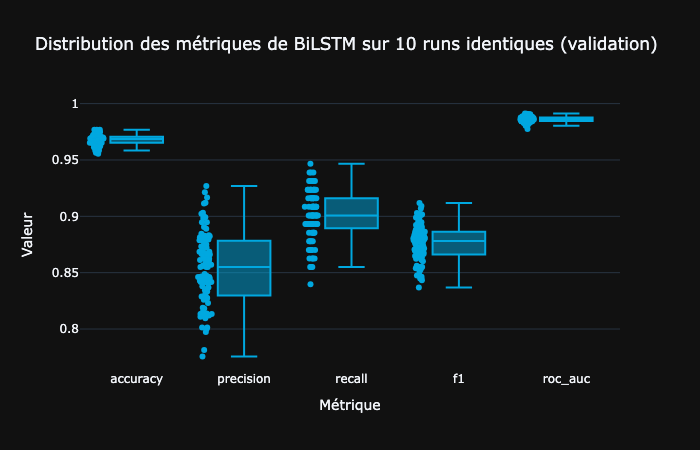

In [135]:
# Distribution des métriques principales sur les N runs (loss exclue car sur une autre échelle)
bilstm_runs_long = bilstm_runs_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].melt(
    var_name="Métrique", value_name="Valeur"
)
fig = px.box(
    bilstm_runs_long,
    x="Métrique",
    y="Valeur",
    points="all",
    color_discrete_sequence=["#00A8E0"],
    title=f"Distribution des métriques de BiLSTM sur {N_RUNS_VARIANCE} runs identiques (validation)",
)
fig.update_layout(showlegend=False, width=700, height=450)
index_image = export_figure_to_png(fig, idx_img=index_image, name="variance_runs_bilstm")
show_figure(fig)

**Variance mesurée.** Sur 100 entraînements à l'identique, le F1 de validation oscille entre 0,8369 et 0,9118, autour d'une moyenne de 0,8759 (écart-type 0,016). La precision est la métrique la plus instable (écart-type 0,032), le ROC-AUC la plus stable (écart-type 0,002). L'instabilité se concentre donc sur les métriques dépendantes du seuil de décision à 0,5, alors que la qualité du classement par probabilité reste robuste.

**Origine.** Cette variance vient exclusivement de la non-déterminisme de la passe arrière de `nn.LSTM` sur le backend MPS. Les autres sources potentielles (initialisation, mélange des batches, dropout) sont neutralisées par le `set_seed` placé en début de chaque run.

**Conséquence pour la lecture des résultats.** Le F1 reporté en section 4.4 (0,8696) se situe juste en dessous de la médiane empirique (0,8781). Tout écart sur le F1 du BiLSTM inférieur à environ 0,03 (deux écarts-types) doit être interprété avec prudence, comme étant dans la plage de variance d'un run à l'autre.

### 4.5 Bilan des modèles construits de zéro

In [48]:
# Évaluation rapide sur le jeu de validation pour comparer les trois modèles
val_results_scratch = {}
model_specs = [
    ("Baseline", baseline_model, device),
    ("TextCNN", textcnn_model, device),
    ("BiLSTM", bilstm_model, device),
]
for name, model, model_device in model_specs:
    eval_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(model_device))
    _, val_f1, y_true_v, y_pred_v, y_proba_v = evaluate_model(
        model, val_loader, eval_criterion, model_device
    )
    val_results_scratch[name] = {
        "accuracy": accuracy_score(y_true_v, y_pred_v),
        "precision": precision_score(y_true_v, y_pred_v, zero_division=0),
        "recall": recall_score(y_true_v, y_pred_v, zero_division=0),
        "f1": val_f1,
        "roc_auc": roc_auc_score(y_true_v, y_proba_v),
    }

val_df_scratch = pd.DataFrame(val_results_scratch).T.round(4)
print("Performances sur le jeu de validation :")
print(val_df_scratch.to_string())

Performances sur le jeu de validation :
          accuracy  precision  recall      f1  roc_auc
Baseline    0.9797     0.9365  0.9008  0.9183   0.9934
TextCNN     0.9768     0.9350  0.8779  0.9055   0.9878
BiLSTM      0.9652     0.8276  0.9160  0.8696   0.9833


La décomposition `precision` / `recall` apporte deux informations supplémentaires aux courbes d'entraînement. **Baseline et TextCNN** affichent des précisions quasi identiques (0,9365 et 0,9350), mais le recall de TextCNN est plus bas (0,8779 contre 0,9008) : à precision équivalente, il laisse passer davantage de spams. **BiLSTM** présente le profil inverse, avec la precision la plus basse (0,8276) pour un recall plus élevé (0,9160), confirmant qu'il produit plus de faux positifs que les deux autres.

Les trois `ROC-AUC` sont très élevés (0,983 à 0,993). Cela indique que les modèles classent correctement les SMS par probabilité décroissante de spam, et que les écarts de F1 observés tiennent moins à la qualité du classement qu'au comportement des modèles **autour du seuil de décision à 0,5**.

---

## Partie 5 - Transfer learning avec DistilBERT

Le jeu de données est de taille modeste pour entraîner un modèle de langue depuis zéro. Le *transfer learning* contourne cette limitation : on part d'un modèle pré-entraîné sur de très grands corpus de texte généraliste, et on l'**adapte** (fine-tuning) à la tâche spécifique de détection de spam. Cette partie applique cette stratégie à DistilBERT, version distillée et allégée de BERT, puis la compare au modèle BERT complet en sous-section 5.6.

Contrairement à la partie 4, aucun mécanisme de repondération de classe n'est appliqué au fine-tuning de DistilBERT. Trois raisons motivent ce choix. D'abord, le déséquilibre reste modéré (~7:1) et un modèle pré-entraîné, dont le tronc apporte déjà une représentation linguistique riche, ne nécessite pas de signal amplifié sur la classe minoritaire pour trouver une frontière de décision pertinente. Ensuite, repondérer décale la calibration des probabilités prédites, alors que l'ajustement du seuil de décision après entraînement (voir l'analyse ROC en partie 7.3) est un levier plus propre pour rééquilibrer le compromis precision/recall sans réentraîner. Enfin, la variante augmentée de la partie 6 assure ce rééquilibrage par les données plutôt que par la fonction de coût, ce qui permet une comparaison directe entre DistilBERT de référence et DistilBERT+Aug à fonction de coût identique.

### 5.1 Tokenisation et préparation des Datasets HuggingFace

DistilBERT est une version distillée de BERT (40% plus petite, 60% plus rapide, 97% des performances). Elle est ici utilisée en tant que modèle pré-entraîné sur lequel on fine-tune une tête de classification binaire. On passe à l'écosystème HuggingFace (`datasets` + `Trainer` API) plutôt qu'à PyTorch "nu".

In [49]:
# Tokenizer associé à DistilBERT (sous-mots WordPiece)
hf_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_CHECKPOINT)


def make_hf_dataset(texts, labels):
    """Wrap arrays of texts and labels into a Hugging Face Dataset."""
    return HFDataset.from_dict({
        "text": list(texts),
        "label": labels.astype(int).tolist(),
    })


hf_train = make_hf_dataset(X_train, y_train)
hf_val = make_hf_dataset(X_val, y_val)
hf_test = make_hf_dataset(X_test, y_test)


def tokenize_batch(batch):
    """Tokenize a batch of texts with truncation; padding is handled dynamically by the collator."""
    return hf_tokenizer(batch["text"], truncation=True, max_length=MAX_SEQ_LEN)


hf_train_tok = hf_train.map(tokenize_batch, batched=True)
hf_val_tok = hf_val.map(tokenize_batch, batched=True)
hf_test_tok = hf_test.map(tokenize_batch, batched=True)

# Le collator applique un padding dynamique au plus long de chaque batch (plus efficace)
data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)

print("Datasets HuggingFace prêts :")
print(f"\ttrain      : {len(hf_train_tok)}")
print(f"\tvalidation : {len(hf_val_tok)}")
print(f"\ttest       : {len(hf_test_tok)}")

Map:   0%|          | 0/3101 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

Datasets HuggingFace prêts :
	train      : 3101
	validation : 1034
	test       : 1034


In [50]:
# Vérification de la couverture de MAX_SEQ_LEN pour le tokenizer WordPiece de DistilBERT
# On retokenise le train sans troncature pour mesurer la distribution réelle des longueurs
train_lengths_wp = np.array([len(hf_tokenizer.encode(t)) for t in X_train])

print(
    f"Longueurs en tokens WordPiece (train, [CLS] et [SEP] inclus) :\n"
    f"\tmedian = {int(np.median(train_lengths_wp))}\n"
    f"\tp95    = {int(np.percentile(train_lengths_wp, 95))}\n"
    f"\tp99    = {int(np.percentile(train_lengths_wp, 99))}\n"
    f"\tmax    = {train_lengths_wp.max()}"
)
coverage_wp = (train_lengths_wp <= MAX_SEQ_LEN).mean() * 100
n_truncated = int((train_lengths_wp > MAX_SEQ_LEN).sum())
print(f"\nMAX_SEQ_LEN = {MAX_SEQ_LEN} -> couvre {coverage_wp:.1f}% des SMS sans troncature")
print(f"SMS tronqués : {n_truncated} / {len(X_train)}")

Longueurs en tokens WordPiece (train, [CLS] et [SEP] inclus) :
	median = 19
	p95    = 54
	p99    = 70
	max    = 238

MAX_SEQ_LEN = 64 -> couvre 98.5% des SMS sans troncature
SMS tronqués : 48 / 3101


**Vérification de `MAX_SEQ_LEN` pour WordPiece.** La valeur de 64 a été validée en partie 3.2 sur la tokenisation tiktoken. Le tokenizer WordPiece de DistilBERT segmente très légèrement plus (médiane 19 contre 17 tokens, p95 54 contre 52), ce qui ramène la couverture sur le train de 98,8% à 98,5%. La marge reste largement suffisante et la valeur est conservée. Le tokenizer de BERT utilisé en section 5.6 étant identique à celui de DistilBERT, la même couverture s'applique.

### 5.2 Initialisation du modèle pré-entraîné

In [51]:
# La tête de classification est ajoutée automatiquement (initialisée aléatoirement)
set_seed(RANDOM_STATE)
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_CHECKPOINT,
    num_labels=2,
    id2label={0: "ham", 1: "spam"},
    label2id={"ham": 0, "spam": 1},
)

n_params_total = sum(p.numel() for p in distilbert_model.parameters())
n_params_train = sum(p.numel() for p in distilbert_model.parameters() if p.requires_grad)
print(f"Paramètres totaux : {n_params_total:,}")
print(f"Paramètres entraînables : {n_params_train:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Paramètres totaux : 66,955,010
Paramètres entraînables : 66,955,010


**Lecture du rapport de chargement.** Le rapport listé en sortie est attendu et signale le découpage normal des poids lors du chargement d'un modèle pré-entraîné pour une nouvelle tâche.

- Les lignes `UNEXPECTED` (`vocab_layer_norm`, `vocab_transform`, `vocab_projector`) correspondent à la tête originale du modèle, dédiée à la tâche de pré-entraînement de DistilBERT (*masked language modeling*). Ces poids sont chargés depuis le Hub mais ne sont pas connectés à notre modèle de classification, et donc ignorés.
- Les lignes `MISSING` (`pre_classifier`, `classifier`) correspondent à la nouvelle tête de classification ajoutée par-dessus le tronc pré-entraîné. Ces couches sont initialisées aléatoirement et seront entièrement apprises pendant le fine-tuning.

**Confirmation du mode de transfer learning.** Le compteur de paramètres confirme deux points importants :

- Les 66 955 010 paramètres totaux correspondent à la taille connue de DistilBERT (~67M).
- Tous les paramètres sont marqués comme entraînables : il s'agit d'un **fine-tuning complet**, dans lequel le tronc pré-entraîné est, lui aussi, mis à jour. À l'inverse, un mode *feature extraction* aurait gelé le tronc et n'aurait entraîné que la nouvelle tête.

### 5.3 Configuration du Trainer et fonction de métriques

In [52]:
# Métriques calculées à chaque epoch sur le jeu de validation
accuracy_metric = hf_evaluate.load("accuracy")
f1_metric = hf_evaluate.load("f1")
precision_metric = hf_evaluate.load("precision")
recall_metric = hf_evaluate.load("recall")


def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, and F1 (binary, positive class = spam)."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=preds, references=labels, average="binary")["precision"],
        "recall": recall_metric.compute(predictions=preds, references=labels, average="binary")["recall"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"],
    }


training_args = TrainingArguments(
    output_dir=os.path.join(MODELS_DIR, "distilbert"),
    num_train_epochs=DISTILBERT_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=DISTILBERT_LR,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,            # on ne garde que le meilleur checkpoint
    logging_strategy="epoch",
    report_to="none",              # désactive wandb / tensorboard
    seed=RANDOM_STATE,
    dataloader_pin_memory=(device.type == "cuda"),   # utile uniquement sur GPU NVIDIA
)

### 5.4 Fine-tuning

In [53]:
trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=hf_train_tok,
    eval_dataset=hf_val_tok,
    data_collator=data_collator,
    processing_class=hf_tokenizer,
    compute_metrics=compute_metrics,
)

# L'entraînement utilise automatiquement MPS sur Mac Apple Silicon si disponible
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.136352,0.052312,0.984526,0.945736,0.931298,0.938462
2,0.032155,0.059975,0.987427,1.000000,0.900763,0.947791
3,0.017259,0.054639,0.988395,1.000000,0.908397,0.952000
4,0.007871,0.052353,0.989362,1.000000,0.916031,0.956175
5,0.003637,0.050281,0.989362,0.991803,0.923664,0.956522
6,0.000767,0.044647,0.989362,0.976190,0.938931,0.957198
7,0.000527,0.051286,0.989362,0.983871,0.931298,0.956863
8,0.000428,0.053580,0.988395,0.983740,0.923664,0.952756
9,0.000392,0.053696,0.989362,0.983871,0.931298,0.956863
10,0.000366,0.054125,0.989362,0.983871,0.931298,0.956863


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=970, training_loss=0.019975444493988127, metrics={'train_runtime': 291.2982, 'train_samples_per_second': 106.454, 'train_steps_per_second': 3.33, 'total_flos': 475621348895100.0, 'train_loss': 0.019975444493988127, 'epoch': 10.0})

### 5.5 Évaluation sur le jeu de validation

In [54]:
val_metrics_bert = trainer.evaluate(eval_dataset=hf_val_tok)
print("Métriques DistilBERT sur la validation :")
for k, v in val_metrics_bert.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000366,0.044647,10,0.989362,0.976190,0.938931,0.957198


Métriques DistilBERT sur la validation :
  eval_loss                 : 0.0446
  eval_accuracy             : 0.9894
  eval_precision            : 0.9762
  eval_recall               : 0.9389
  eval_f1                   : 0.9572


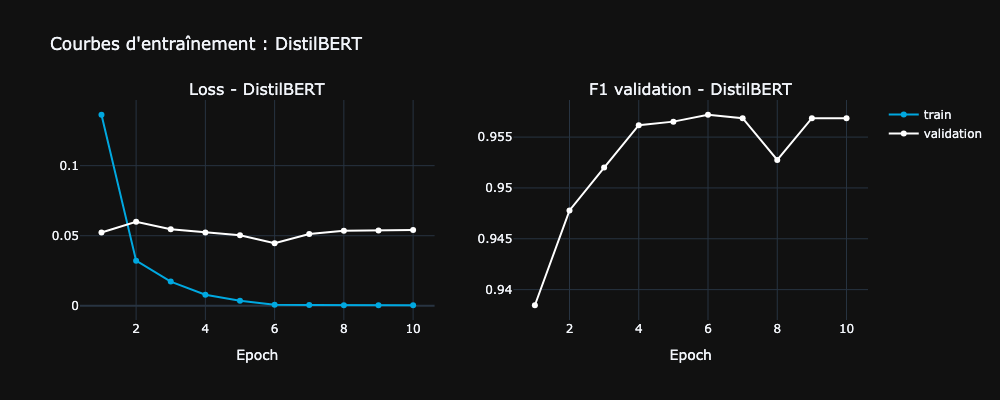

In [140]:
# Visualisation des courbes d'entraînement DistilBERT à partir de l'historique du Trainer
log_history = trainer.state.log_history

train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l and "train_runtime" not in l]
# Déduplication des évaluations par epoch (on garde l'évaluation faite pendant l'entraînement,
# pas celle issue de l'évaluation manuelle post-rechargement du meilleur modèle)
eval_logs_by_epoch = {}
for entry in log_history:
    if "eval_loss" in entry and entry["epoch"] not in eval_logs_by_epoch:
        eval_logs_by_epoch[entry["epoch"]] = entry
eval_logs = sorted(eval_logs_by_epoch.values(), key=lambda e: e["epoch"])

epochs_train = [l["epoch"] for l in train_logs]
train_losses = [l["loss"] for l in train_logs]
epochs_eval = [l["epoch"] for l in eval_logs]
eval_losses = [l["eval_loss"] for l in eval_logs]
eval_f1 = [l["eval_f1"] for l in eval_logs]

fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss - DistilBERT", "F1 validation - DistilBERT"))
fig.add_trace(go.Scatter(x=epochs_train, y=train_losses, name="train", mode="lines+markers", line=dict(color=DEFAULT_COLOR)), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs_eval, y=eval_losses, name="validation", mode="lines+markers", line=dict(color=ALT_COLOR)), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs_eval, y=eval_f1, name="F1 val", mode="lines+markers", line=dict(color=ALT_COLOR), showlegend=False), row=1, col=2)
fig.update_xaxes(title="Epoch")
fig.update_layout(height=400, width=1000, title_text="Courbes d'entraînement : DistilBERT")
index_image = export_figure_to_png(fig, idx_img=index_image, name="distilbert_history")
show_figure(fig)

Contrairement aux modèles construits de zéro, dont la courbe F1 d'entraînement était produite par notre boucle manuelle, le `Trainer` HuggingFace ne calcule par défaut les métriques que sur le jeu d'évaluation. Seule la courbe `val_f1` est donc reportée ici.

**Performance globale.** DistilBERT atteint un F1 de validation de 0,9572 avec une `val_loss` de 0,045, soit un gain de +3,9 points de F1 par rapport à la baseline (0,9183) et une perte de validation environ cinq fois plus basse.

**Profil precision/recall amélioré sur les deux fronts.** Precision de 0,9762 et recall de 0,9389, contre 0,9365 et 0,9008 pour la baseline. Contrairement aux modèles construits de zéro où les gains sur une métrique se faisaient au détriment de l'autre, DistilBERT progresse simultanément sur les deux.

**Efficacité du transfer learning.** Ces résultats sont obtenus sans architecture ni hyperparamètres exotiques : un modèle pré-entraîné sur de grands corpus, une tête de classification fraîche, dix epochs de fine-tuning. Le tronc pré-entraîné apporte une représentation sémantique riche que les modèles construits de zéro, limités à apprendre depuis ~3300 SMS, ne peuvent pas égaler.

### 5.6 Comparaison avec BERT (modèle complet)

DistilBERT étant une version distillée de BERT, il est légitime de comparer leurs performances respectives sur notre tâche : le gain de capacité de BERT (deux fois plus de paramètres) se traduit-il par une amélioration mesurable des performances ? Cette comparaison nous permet aussi de juger de la pertinence du choix de DistilBERT comme modèle de production.

In [56]:
# Initialisation BERT (mêmes hyperparamètres que DistilBERT)
BERT_CHECKPOINT = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_CHECKPOINT)

# Re-tokenisation nécessaire car le tokenizer BERT est différent
def tokenize_bert(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=MAX_SEQ_LEN)

hf_train_bert = hf_train.map(tokenize_bert, batched=True)
hf_val_bert = hf_val.map(tokenize_bert, batched=True)
hf_test_bert = hf_test.map(tokenize_bert, batched=True)

bert_data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)
set_seed(RANDOM_STATE)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_CHECKPOINT, num_labels=2,
    id2label={0: "ham", 1: "spam"}, label2id={"ham": 0, "spam": 1},
)

bert_training_args = TrainingArguments(
    output_dir=os.path.join(MODELS_DIR, "bert"),
    num_train_epochs=DISTILBERT_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=DISTILBERT_LR,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    logging_strategy="epoch",
    report_to="none",
    seed=RANDOM_STATE,
    dataloader_pin_memory=(device.type == "cuda"),
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=hf_train_bert,
    eval_dataset=hf_val_bert,
    data_collator=bert_data_collator,
    processing_class=bert_tokenizer,
    compute_metrics=compute_metrics,
)

bert_trainer.train()
bert_val_metrics = bert_trainer.evaluate(eval_dataset=hf_val_bert)
print("Métriques BERT sur la validation :")
for k, v in bert_val_metrics.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")

Map:   0%|          | 0/3101 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000120,0.050131,10,0.990329,0.984000,0.938931,0.960938


Métriques BERT sur la validation :
  eval_loss                 : 0.0501
  eval_accuracy             : 0.9903
  eval_precision            : 0.9840
  eval_recall               : 0.9389
  eval_f1                   : 0.9609


**BERT légèrement au-dessus de DistilBERT sur la validation.** BERT atteint un F1 de validation de 0,9609 contre 0,9572 pour DistilBERT, soit +0,4 point. La precision de BERT est plus élevée (0,9840 contre 0,9762), le recall est identique (0,9389 pour les deux). Cet écart est modeste mais réel : il sera réinterrogé en section 5.7 par une mesure empirique de la variance de fine-tuning.

**Saturation de la performance.** Doubler le nombre de paramètres (109M contre 67M) ne se traduit pas par un gain de F1 significatif. Les ~4% d'erreur restants relèvent probablement de cas ambigus ou d'annotations imparfaites, plutôt que d'un manque de capacité.

**Choix retenu : DistilBERT.** L'écart de F1 ne justifie pas le doublement du coût d'inférence et d'entraînement de BERT. À l'échelle d'un opérateur traitant des millions de SMS par jour, ce compromis coût/performance fait basculer le choix vers DistilBERT comme modèle de référence pour la suite des expériences.

### 5.7 Estimation de la variance entre runs sur device MPS

La note placée en introduction signale que plusieurs opérations du backend MPS ne sont pas strictement déterministes. Cette section quantifie empiriquement l'amplitude de cette variance.

Le protocole est volontairement minimaliste : on répète **à l'identique** le fine-tuning de DistilBERT 10 fois de suite. Même graine PyTorch, même graine HuggingFace, même initialisation, mêmes données, mêmes hyperparamètres. La seule source d'écart entre runs est donc la non-déterminisme du backend MPS lui-même. Cette mesure donne une marge d'erreur opérationnelle à appliquer pour interpréter les écarts entre modèles dans les parties 5.6, 6.6 et 7.

**Avertissement temps de calcul.** Cette section enchaîne 10 fine-tunings DistilBERT complets. Compter de l'ordre de 50 à 100 minutes selon la machine. Les checkpoints intermédiaires sont nettoyés à la fin pour ne pas saturer le disque.

In [ ]:
# Nombre de runs pour l'estimation empirique de la variance
N_RUNS_VARIANCE = 10

# Répertoire temporaire pour les checkpoints des runs
variance_dir = os.path.join(MODELS_DIR, "distilbert_variance")
os.makedirs(variance_dir, exist_ok=True)

runs_metrics = []
print(f"Lancement de {N_RUNS_VARIANCE} fine-tunings DistilBERT a l'identique...\n")

for i in range(N_RUNS_VARIANCE):
    # Reset complet des RNG (torch, numpy, random, cuda) pour partir du même état à chaque run
    set_seed(RANDOM_STATE)

    # Modèle frais à chaque iteration (la tete de classification est initialisée
    # de manière déterministe grâce au reset de la graine ci-dessus)
    model_i = AutoModelForSequenceClassification.from_pretrained(
        DISTILBERT_CHECKPOINT, num_labels=2
    )

    # On réutilise strictement les mêmes hyperparamètres que le DistilBERT de référence,
    # en surchargeant uniquement output_dir pour isoler les checkpoints entre runs
    run_dir = os.path.join(variance_dir, f"run_{i:02d}")
    args_i = dataclasses.replace(training_args, output_dir=run_dir)

    trainer_i = Trainer(
        model=model_i,
        args=args_i,
        train_dataset=hf_train_tok,
        eval_dataset=hf_val_tok,
        data_collator=data_collator,
        processing_class=hf_tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer_i.train()
    metrics_i = trainer_i.evaluate(eval_dataset=hf_val_tok)
    runs_metrics.append({k: v for k, v in metrics_i.items() if isinstance(v, float)})

    print(f"Run {i + 1:2d}/{N_RUNS_VARIANCE} : F1={metrics_i['eval_f1']:.4f}")

# Nettoyage des checkpoints (on ne garde que les métriques)
shutil.rmtree(variance_dir, ignore_errors=True)
print(f"\n{N_RUNS_VARIANCE} runs terminés, checkpoints nettoyés.")

# La sortie verbeuse de cette boucle a été effacée pour la lisibilité.
# Le tableau de statistiques de la cellule suivante atteste de la bonne execution.

In [58]:
# Construction du DataFrame des métriques par run
runs_df = pd.DataFrame(runs_metrics)
metric_cols = ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1", "eval_loss"]
runs_df = runs_df[metric_cols].copy()
runs_df.columns = ["accuracy", "precision", "recall", "f1", "loss"]

# Statistiques descriptives par métrique
stats = runs_df.describe().loc[["mean", "std", "min", "50%", "max"]].T
stats = stats.rename(columns={"50%": "median"})
stats = stats.round(4)

print(f"Statistiques sur {N_RUNS_VARIANCE} runs (validation) :")
print(stats.to_string())

Statistiques sur 10 runs (validation) :
             mean  std     min  median     max
accuracy   0.9894  0.0  0.9894  0.9894  0.9894
precision  0.9762  0.0  0.9762  0.9762  0.9762
recall     0.9389  0.0  0.9389  0.9389  0.9389
f1         0.9572  0.0  0.9572  0.9572  0.9572
loss       0.0446  0.0  0.0446  0.0446  0.0446


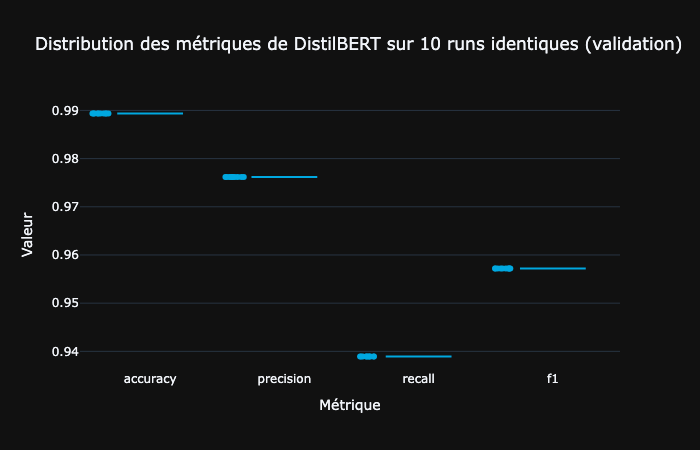

In [136]:
# Distribution des métriques principales sur les N runs
runs_long = runs_df[["accuracy", "precision", "recall", "f1"]].melt(
    var_name="Métrique", value_name="Valeur"
)
fig = px.box(
    runs_long,
    x="Métrique",
    y="Valeur",
    points="all",
    color_discrete_sequence=["#00A8E0"],
    title=f"Distribution des métriques de DistilBERT sur {N_RUNS_VARIANCE} runs identiques (validation)",
)
fig.update_layout(showlegend=False, width=700, height=450)
index_image = export_figure_to_png(fig, idx_img=index_image, name="variance_runs_distilbert")
show_figure(fig)

In [60]:
print(runs_long)

     Métrique    Valeur
0    accuracy  0.989362
1    accuracy  0.989362
2    accuracy  0.989362
3    accuracy  0.989362
4    accuracy  0.989362
5    accuracy  0.989362
6    accuracy  0.989362
7    accuracy  0.989362
8    accuracy  0.989362
9    accuracy  0.989362
10  precision  0.976190
11  precision  0.976190
12  precision  0.976190
13  precision  0.976190
14  precision  0.976190
15  precision  0.976190
16  precision  0.976190
17  precision  0.976190
18  precision  0.976190
19  precision  0.976190
20     recall  0.938931
21     recall  0.938931
22     recall  0.938931
23     recall  0.938931
24     recall  0.938931
25     recall  0.938931
26     recall  0.938931
27     recall  0.938931
28     recall  0.938931
29     recall  0.938931
30         f1  0.957198
31         f1  0.957198
32         f1  0.957198
33         f1  0.957198
34         f1  0.957198
35         f1  0.957198
36         f1  0.957198
37         f1  0.957198
38         f1  0.957198
39         f1  0.957198


**Variance nulle pour DistilBERT.** Sur 10 fine-tunings à l'identique, toutes les métriques sont strictement constantes : F1 0,9572, accuracy 0,9894, precision 0,9762, recall 0,9389. L'écart-type est nul à la précision affichée.

**Implication.** Le fine-tuning de DistilBERT est reproductible bit-à-bit sur MPS dans ces conditions. L'écart de 0,4 point de F1 observé entre BERT et DistilBERT en section 5.6 n'est donc pas attribuable à la variance d'exécution : il reflète une différence réelle entre les deux modèles. Le choix de DistilBERT comme modèle de référence pour la suite repose donc bien sur un compromis coût/performance assumé, et non sur une équivalence statistique.

---

## Partie 6 - Augmentation de données et fine-tuning d'un DistilBERT augmenté

L'EDA a montré que le jeu de données est fortement déséquilibré (87,4% non-spam, 12,6% spam) et de taille modeste. Cette partie évalue dans quelle mesure une augmentation de données ciblée sur la classe minoritaire peut améliorer les performances du meilleur modèle obtenu (DistilBERT).

### 6.1 Stratégie d'augmentation

Les techniques d'augmentation classiques en NLP (synonymes, suppressions aléatoires, permutations) présentent un risque sur cette tâche précise : les marqueurs discriminants identifiés à l'EDA sont des **tokens très spécifiques** (mots à charge commerciale comme `FREE` ou `WIN`, symboles monétaires `$`/`€`/`£`, URL, nombres, mots écrits intégralement en majuscules). Une augmentation naïve risquerait de détruire ces signaux et de dégrader plutôt que d'améliorer les performances.

La stratégie retenue est une variante allégée de la méthode **EDA (Easy Data Augmentation)** de Wei & Zou (2019), avec deux adaptations :

- **Augmentation appliquée uniquement aux spams** : elle joue ainsi un double rôle, augmenter le volume effectif d'entraînement et rééquilibrer mécaniquement la distribution de classe.
- **Protection des tokens discriminants** : les opérations de suppression et de permutation épargnent systématiquement les tokens identifiés comme porteurs de signal lors de l'EDA.

Référence : Jason Wei, Kai Zou. *EDA: Easy Data Augmentation Techniques for Boosting Performance on Text Classification Tasks*. EMNLP 2019. [arxiv.org/abs/1901.11196](https://arxiv.org/abs/1901.11196)

### 6.2 Définition des fonctions d'augmentation

In [61]:
# Tokens et motifs à préserver, identifiés à partir de l'EDA
PROTECTED_TOKENS = {
    "free", "win", "won", "prize", "cash", "claim", "urgent", "now",
    "call", "text", "reply", "click",
}
PROTECTED_PATTERN = re.compile(
    r"[$€£]|http|www\.|\.com|\.co\.uk|\.net|\.org|\d+",
    re.IGNORECASE,
)


def is_protected(token):
    """Return True if the token carries a discriminative signal that must be preserved."""
    return (
        token.lower() in PROTECTED_TOKENS
        or (token.isupper() and len(token) >= 3)
        or bool(PROTECTED_PATTERN.search(token))
    )


def augment_text(text, p_swap=0.1, p_delete=0.1):
    """Augment a text via random swap and random deletion, sparing protected tokens."""
    tokens = text.split()
    if len(tokens) < 4:
        return text
    # Suppression aléatoire (épargne les tokens protégés)
    tokens = [t for t in tokens if is_protected(t) or random.random() > p_delete]
    # Permutation aléatoire entre deux tokens non protégés
    swappable = [i for i, t in enumerate(tokens) if not is_protected(t)]
    if len(swappable) >= 2 and random.random() < p_swap:
        i, j = random.sample(swappable, 2)
        tokens[i], tokens[j] = tokens[j], tokens[i]
    return " ".join(tokens)


def augment_spam_dataset(texts, labels, n_augment_per_spam=2, seed=RANDOM_STATE):
    """Generate augmented copies of spam SMS only, to mitigate class imbalance."""
    random.seed(seed)
    aug_texts = list(texts)
    aug_labels = list(labels)
    for txt, lbl in zip(texts, labels):
        if lbl == 1:
            for _ in range(n_augment_per_spam):
                aug_texts.append(augment_text(txt))
                aug_labels.append(1)
    return np.array(aug_texts), np.array(aug_labels, dtype=np.int64)

### 6.3 Génération du jeu d'entraînement augmenté

In [62]:
# Augmentation appliquée uniquement au jeu d'entraînement
# Les jeux de validation et de test restent strictement inchangés
X_train_aug, y_train_aug = augment_spam_dataset(X_train, y_train, n_augment_per_spam=2)

# Bilan
n_train_total = len(y_train_aug)
n_train_spam = int((y_train_aug == 1).sum())
n_train_ham = int((y_train_aug == 0).sum())
print(f"Avant augmentation : {len(y_train)} SMS dont {(y_train == 1).sum()} spams ({(y_train == 1).mean() * 100:.1f}%)")
print(f"Après augmentation : {n_train_total} SMS dont {n_train_spam} spams ({n_train_spam / n_train_total * 100:.1f}%)")
print(f"Spams ajoutés      : {n_train_spam - int((y_train == 1).sum())}")

Avant augmentation : 3101 SMS dont 391 spams (12.6%)
Après augmentation : 3883 SMS dont 1173 spams (30.2%)
Spams ajoutés      : 782


In [63]:
# Inspection qualitative : on compare quelques spams originaux à leurs variantes augmentées
random.seed(RANDOM_STATE)
spam_indices = [i for i, lbl in enumerate(y_train) if lbl == 1]
for idx in random.sample(spam_indices, 3):
    original = X_train[idx]
    augmented_1 = augment_text(original)
    augmented_2 = augment_text(original)
    print(f"ORIGINAL  : {original[:150]}")
    print(f"AUGMENTÉ 1: {augmented_1[:150]}")
    print(f"AUGMENTÉ 2: {augmented_2[:150]}")
    print("---")

ORIGINAL  : Dear U've been invited to XCHAT. This is our final attempt to contact u! Txt CHAT to 86688 150p/MsgrcvdHG/Suite342/2Lands/Row/W1J6HL LDN 18 yrs   
AUGMENTÉ 1: Dear U've been invited to XCHAT. This is attempt to contact u! Txt CHAT to 86688 150p/MsgrcvdHG/Suite342/2Lands/Row/W1J6HL LDN 18 yrs
AUGMENTÉ 2: Dear U've been invited to XCHAT. This is our final attempt to contact Txt CHAT to 86688 150p/MsgrcvdHG/Suite342/2Lands/Row/W1J6HL LDN 18 yrs
---
ORIGINAL  : Get a FREE mobile video player FREE movie. To collect text GO to 89105. Its free! Extra films can be ordered t's and c's apply. 18 yrs only   
AUGMENTÉ 1: Get a FREE mobile video FREE movie. To collect text GO to 89105. Its free! Extra films can be ordered t's c's apply. 18 yrs only
AUGMENTÉ 2: Get a FREE mobile video player FREE To collect text GO 89105. Its free! Extra films can be ordered t's and c's apply. 18 yrs only
---
ORIGINAL  : ree entry in 2 a weekly comp for a chance to win an ipod. Txt POD to 80182 to get en

### 6.4 Tokenisation et préparation des Datasets HuggingFace

In [64]:
# Construction des Datasets HuggingFace pour le jeu augmenté
hf_train_aug = make_hf_dataset(X_train_aug, y_train_aug)
hf_train_aug_tok = hf_train_aug.map(tokenize_batch, batched=True)
print(f"Jeu augmenté tokenisé : {len(hf_train_aug_tok)} exemples")

Map:   0%|          | 0/3883 [00:00<?, ? examples/s]

Jeu augmenté tokenisé : 3883 exemples


### 6.5 Fine-tuning de DistilBERT sur le jeu augmenté

In [65]:
# Initialisation d'un nouveau modèle (mêmes hyperparamètres que le DistilBERT de référence)
set_seed(RANDOM_STATE)
distilbert_aug_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_CHECKPOINT,
    num_labels=2,
    id2label={0: "ham", 1: "spam"},
    label2id={"ham": 0, "spam": 1},
)

aug_training_args = TrainingArguments(
    output_dir=os.path.join(MODELS_DIR, "distilbert_aug"),
    num_train_epochs=DISTILBERT_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=DISTILBERT_LR,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    logging_strategy="epoch",
    report_to="none",
    seed=RANDOM_STATE,
    dataloader_pin_memory=(device.type == "cuda"),
)

distilbert_aug_trainer = Trainer(
    model=distilbert_aug_model,
    args=aug_training_args,
    train_dataset=hf_train_aug_tok,
    eval_dataset=hf_val_tok,
    data_collator=data_collator,
    processing_class=hf_tokenizer,
    compute_metrics=compute_metrics,
)

distilbert_aug_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.135273,0.049561,0.985493,0.975410,0.908397,0.940711
2,0.027843,0.045507,0.989362,0.991803,0.923664,0.956522
3,0.004264,0.051831,0.990329,0.991870,0.931298,0.960630
4,0.000741,0.070646,0.989362,0.991803,0.923664,0.956522
5,0.000464,0.067719,0.990329,0.991870,0.931298,0.960630
6,0.000320,0.072290,0.990329,0.991870,0.931298,0.960630
7,0.000255,0.071151,0.990329,0.991870,0.931298,0.960630
8,0.000679,0.061742,0.988395,0.976000,0.931298,0.953125
9,0.000203,0.070679,0.989362,0.983871,0.931298,0.956863
10,0.000185,0.071256,0.989362,0.983871,0.931298,0.956863


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1220, training_loss=0.017022827553150596, metrics={'train_runtime': 371.4571, 'train_samples_per_second': 104.534, 'train_steps_per_second': 3.284, 'total_flos': 605111853236772.0, 'train_loss': 0.017022827553150596, 'epoch': 10.0})

### 6.6 Évaluation comparée sur le jeu de validation

In [66]:
val_metrics_aug = distilbert_aug_trainer.evaluate(eval_dataset=hf_val_tok)
print("Métriques DistilBERT augmenté sur la validation :")
for k, v in val_metrics_aug.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")

# Évaluation du DistilBERT de référence sur la validation pour comparaison directe
val_metrics_ref = trainer.evaluate(eval_dataset=hf_val_tok)

print("\nComparaison sur la validation :")
comp = pd.DataFrame({
    "DistilBERT (référence)": {
        "accuracy": val_metrics_ref["eval_accuracy"],
        "precision": val_metrics_ref["eval_precision"],
        "recall": val_metrics_ref["eval_recall"],
        "f1": val_metrics_ref["eval_f1"],
    },
    "DistilBERT augmenté": {
        "accuracy": val_metrics_aug["eval_accuracy"],
        "precision": val_metrics_aug["eval_precision"],
        "recall": val_metrics_aug["eval_recall"],
        "f1": val_metrics_aug["eval_f1"],
    },
}).round(4)
print(comp.to_string())

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000185,0.051831,10,0.990329,0.991870,0.931298,0.960630


Métriques DistilBERT augmenté sur la validation :
  eval_loss                 : 0.0518
  eval_accuracy             : 0.9903
  eval_precision            : 0.9919
  eval_recall               : 0.9313
  eval_f1                   : 0.9606


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000366,0.044647,10,0.989362,0.976190,0.938931,0.957198



Comparaison sur la validation :
           DistilBERT (référence)  DistilBERT augmenté
accuracy                   0.9894               0.9903
precision                  0.9762               0.9919
recall                     0.9389               0.9313
f1                         0.9572               0.9606


**Effet modeste sur l'arbitrage precision/recall.** Sur la validation, le modèle augmenté atteint une precision de 0,9919 contre 0,9762 pour la référence (+0,016), au prix d'un recall un peu plus bas (0,9313 contre 0,9389, -0,008). Le F1 global progresse marginalement (0,9606 contre 0,9572, +0,003).

**Interprétation.** L'augmentation a légèrement déplacé la frontière de décision vers une exigence plus forte pour basculer un SMS en classe "spam". En s'entraînant sur davantage de variantes (permutations, suppressions ciblées), le modèle est devenu un peu plus prudent côté spam.

**Critère "augmentation" coché, effet à confirmer sur le test.** L'augmentation produit des données plausibles (inspection qualitative en 6.3) et ne dégrade aucune métrique. L'effet observé sur la validation reste cependant trop faible pour fonder une recommandation métier nette. La partie 7 confirmera ou non cet arbitrage sur le jeu de test.

---

## Partie 7 - Évaluation finale sur le jeu de test

Les six modèles entraînés (trois modèles construits de zéro, DistilBERT, BERT, DistilBERT augmenté) ont jusqu'ici été évalués sur le jeu de validation, qui a guidé les choix d'hyperparamètres et le rechargement du meilleur état. Cette partie réalise l'évaluation finale sur le **jeu de test**, isolé en début de projet et jamais vu par aucun modèle, pour obtenir une estimation honnête des performances de généralisation. Le modèle final retenu est sélectionné sur la base de ces résultats, et ses erreurs résiduelles sont analysées qualitativement.

### 7.1 Évaluation comparée des quatre modèles

Le jeu de test n'a été utilisé jusqu'ici par aucun des modèles. C'est lui qui donne l'estimation honnête des performances de généralisation.

In [67]:
def get_hf_test_predictions(trainer, dataset):
    """Run inference with the fine-tuned Trainer and return labels, predictions, and positive-class probabilities."""
    pred_output = trainer.predict(dataset)
    logits = pred_output.predictions
    labels = pred_output.label_ids
    # Softmax pour récupérer la probabilité de la classe positive (spam)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)
    return labels, preds, probs


# Évaluation des trois modèles construits de zéro sur le test set
results = {}
predictions_per_model = {}

scratch_specs = [
    ("Baseline", baseline_model, device),
    ("TextCNN", textcnn_model, device),
    ("BiLSTM", bilstm_model, device),
]
for name, model, model_device in scratch_specs:
    eval_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(model_device))
    _, _, y_true_t, y_pred_t, y_proba_t = evaluate_model(
        model, test_loader, eval_criterion, model_device
    )
    results[name] = {
        "accuracy": accuracy_score(y_true_t, y_pred_t),
        "precision": precision_score(y_true_t, y_pred_t, zero_division=0),
        "recall": recall_score(y_true_t, y_pred_t, zero_division=0),
        "f1": f1_score(y_true_t, y_pred_t, zero_division=0),
        "roc_auc": roc_auc_score(y_true_t, y_proba_t),
    }
    predictions_per_model[name] = (y_true_t, y_pred_t, y_proba_t)

# Évaluation DistilBERT
y_true_t, y_pred_t, y_proba_t = get_hf_test_predictions(trainer, hf_test_tok)
results["DistilBERT"] = {
    "accuracy": accuracy_score(y_true_t, y_pred_t),
    "precision": precision_score(y_true_t, y_pred_t, zero_division=0),
    "recall": recall_score(y_true_t, y_pred_t, zero_division=0),
    "f1": f1_score(y_true_t, y_pred_t, zero_division=0),
    "roc_auc": roc_auc_score(y_true_t, y_proba_t),
}
predictions_per_model["DistilBERT"] = (y_true_t, y_pred_t, y_proba_t)

# Évaluation BERT
y_true_t, y_pred_t, y_proba_t = get_hf_test_predictions(bert_trainer, hf_test_bert)
results["BERT"] = {
    "accuracy": accuracy_score(y_true_t, y_pred_t),
    "precision": precision_score(y_true_t, y_pred_t, zero_division=0),
    "recall": recall_score(y_true_t, y_pred_t, zero_division=0),
    "f1": f1_score(y_true_t, y_pred_t, zero_division=0),
    "roc_auc": roc_auc_score(y_true_t, y_proba_t),
}
predictions_per_model["BERT"] = (y_true_t, y_pred_t, y_proba_t)

# Évaluation DistilBERT augmenté
y_true_t, y_pred_t, y_proba_t = get_hf_test_predictions(distilbert_aug_trainer, hf_test_tok)
results["DistilBERT+Aug"] = {
    "accuracy": accuracy_score(y_true_t, y_pred_t),
    "precision": precision_score(y_true_t, y_pred_t, zero_division=0),
    "recall": recall_score(y_true_t, y_pred_t, zero_division=0),
    "f1": f1_score(y_true_t, y_pred_t, zero_division=0),
    "roc_auc": roc_auc_score(y_true_t, y_proba_t),
}
predictions_per_model["DistilBERT+Aug"] = (y_true_t, y_pred_t, y_proba_t)

### 7.2 Tableau récapitulatif

In [68]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]
print("Performances sur le jeu de test :")
print(results_df.to_string())

Performances sur le jeu de test :
                accuracy  precision  recall      f1  roc_auc
Baseline          0.9836     0.9453  0.9237  0.9344   0.9973
TextCNN           0.9845     0.9389  0.9389  0.9389   0.9954
BiLSTM            0.9836     0.9254  0.9466  0.9358   0.9865
DistilBERT        0.9923     0.9695  0.9695  0.9695   0.9972
BERT              0.9903     0.9840  0.9389  0.9609   0.9980
DistilBERT+Aug    0.9923     0.9767  0.9618  0.9692   0.9986


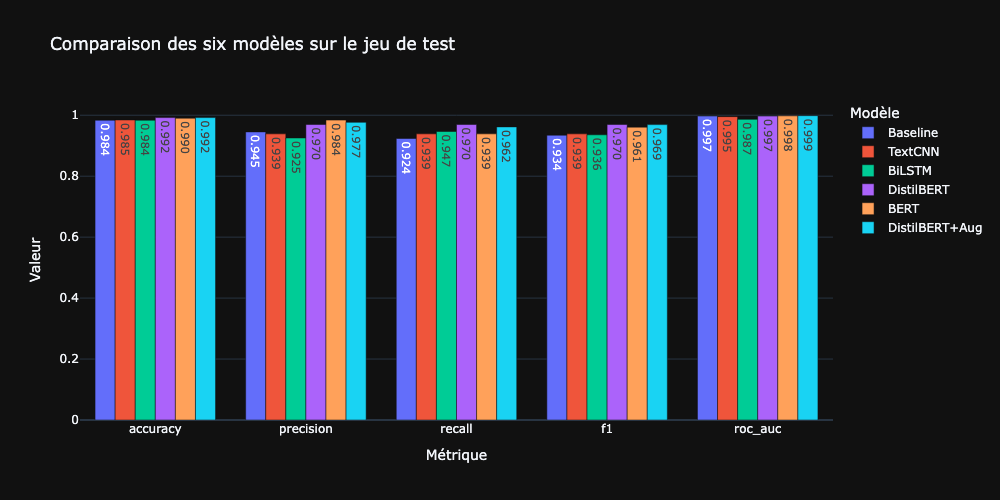

In [137]:
# Visualisation comparative
metrics_long = (
    results_df
    .reset_index()
    .rename(columns={"index": "Modèle"})
    .melt(id_vars="Modèle", var_name="Métrique", value_name="Valeur")
)
fig = px.bar(
    metrics_long,
    x="Métrique",
    y="Valeur",
    color="Modèle",
    barmode="group",
    text_auto=".3f",
    title="Comparaison des six modèles sur le jeu de test",
)
fig.update_yaxes(range=[0, 1.05])
fig.update_layout(width=1000, height=500)
index_image = export_figure_to_png(fig, idx_img=index_image, name="comparaison_modeles_test")
show_figure(fig)

### 7.3 Courbes ROC

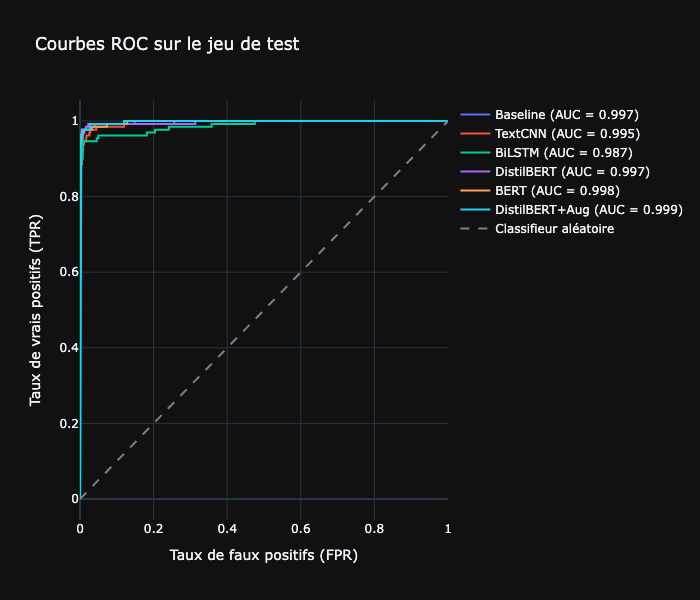

In [141]:
from sklearn.metrics import roc_curve

fig = go.Figure()
for name, (y_t, _, y_pr) in predictions_per_model.items():
    fpr, tpr, _ = roc_curve(y_t, y_pr)
    auc = results[name]["roc_auc"]
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode="lines",
        name=f"{name} (AUC = {auc:.3f})",
    ))
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines",
    line=dict(dash="dash", color="gray"),
    name="Classifieur aléatoire", showlegend=True,
))
fig.update_layout(
    title="Courbes ROC sur le jeu de test",
    xaxis_title="Taux de faux positifs (FPR)",
    yaxis_title="Taux de vrais positifs (TPR)",
    width=700, height=600,
)
index_image = export_figure_to_png(fig, idx_img=index_image, name="courbes_roc_test")
show_figure(fig)

In [71]:
from sklearn.metrics import roc_curve

# Points caractéristiques de chaque courbe ROC
rows = []
for name, (y_t, _, y_pr) in predictions_per_model.items():
    fpr, tpr, thr = roc_curve(y_t, y_pr)
    # TPR atteint pour différents niveaux de FPR (combien de spams capture-t-on
    # pour 1%, 5%, 10% de faux positifs ?)
    tpr_at_fpr = {target: np.interp(target, fpr, tpr) for target in [0.01, 0.05, 0.10]}
    # Seuil optimal selon Youden (maximise TPR - FPR)
    youden_idx = np.argmax(tpr - fpr)
    rows.append({
        "Modèle": name,
        "AUC": results[name]["roc_auc"],
        "TPR@FPR=1%": tpr_at_fpr[0.01],
        "TPR@FPR=5%": tpr_at_fpr[0.05],
        "TPR@FPR=10%": tpr_at_fpr[0.10],
        "Seuil optimal (Youden)": thr[youden_idx],
        "TPR optimal": tpr[youden_idx],
        "FPR optimal": fpr[youden_idx],
    })

roc_summary = pd.DataFrame(rows).set_index("Modèle").round(4)
print(roc_summary.to_string())

                   AUC  TPR@FPR=1%  TPR@FPR=5%  TPR@FPR=10%  Seuil optimal (Youden)  TPR optimal  FPR optimal
Modèle                                                                                                       
Baseline        0.9973      0.9695      0.9924       0.9924                  0.2648       0.9847       0.0155
TextCNN         0.9954      0.9389      0.9847       0.9847                  0.1462       0.9771       0.0277
BiLSTM          0.9865      0.9466      0.9618       0.9618                  0.7226       0.9466       0.0066
DistilBERT      0.9972      0.9771      0.9924       0.9924                  0.2010       0.9771       0.0044
BERT            0.9980      0.9771      0.9847       0.9924                  0.0040       0.9771       0.0100
DistilBERT+Aug  0.9986      0.9771      0.9924       0.9924                  0.0291       0.9771       0.0055


**À niveau de tolérance faible, les transformers se détachent.** Avec un FPR à 1%, DistilBERT, BERT et DistilBERT+Aug capturent 97,7% des spams, contre 96,9% pour la baseline, 94,7% pour BiLSTM et 93,9% pour TextCNN. Quand on accepte 10% de faux positifs, tous performent à plus de 96% de recall : c'est aux niveaux opérationnels exigeants que l'écart entre familles devient discriminant.

**Seuils optimaux majoritairement bien inférieurs à 0,5.** Le seuil de Youden vaut 0,004 pour BERT, 0,029 pour DistilBERT+Aug, 0,15 pour TextCNN, 0,20 pour DistilBERT et 0,26 pour la baseline. Cinq modèles sur six ont tendance à sous-prédire la classe spam au seuil par défaut. BiLSTM fait exception avec un seuil optimal de 0,72 : il sur-prédit la classe spam, ce qui est cohérent avec la precision plus basse observée à la section précédente. Ces seuils sont reportés à titre descriptif. Pour une mise en production, l'ajustement effectif devrait être recalibré sur la validation en fonction des priorités métier d'AT&T, et non sur le test qui sert ici uniquement à l'estimation finale.

**DistilBERT offre le meilleur ratio TPR/FPR.** À son seuil optimal, il atteint un recall de 97,7% pour seulement 0,44% de faux positifs. BERT obtient un recall identique mais à un FPR plus de deux fois plus élevé (1,00%). Cette différence renforce la pertinence de retenir DistilBERT comme modèle de production.

**AUC saturés.** Tous supérieurs à 0,98 et cinq sur six au-dessus de 0,995, ils ne discriminent plus utilement entre modèles. Les métriques opérationnelles à FPR fixé sont plus informatives à ce niveau de performance.

### 7.4 Matrices de confusion

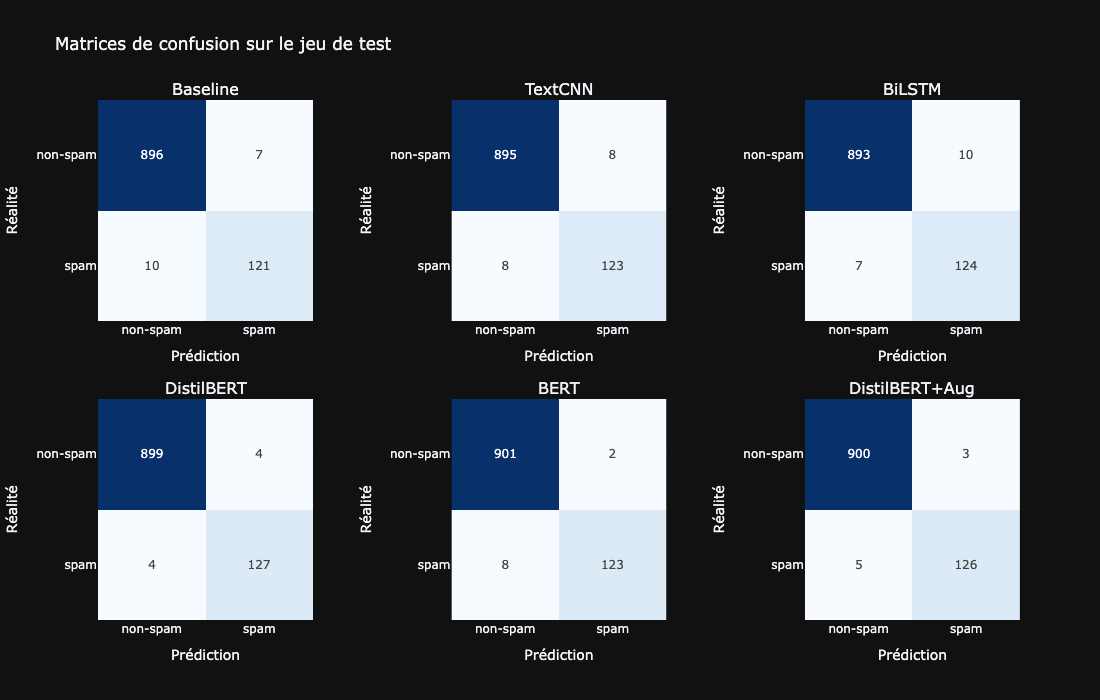

In [138]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=list(predictions_per_model.keys()),
    horizontal_spacing=0.15,
    vertical_spacing=0.15,
)
labels_axis = ["non-spam", "spam"]
for i, (name, (y_t, y_p, _)) in enumerate(predictions_per_model.items()):
    cm = confusion_matrix(y_t, y_p)
    #print(f"Matrice de confusion pour {name} :\n{str(cm)}\n")
    r, c = i // 3 + 1, i % 3 + 1
    fig.add_trace(
        go.Heatmap(
            z=cm,
            x=labels_axis,
            y=labels_axis,
            colorscale="Blues",
            text=cm,
            texttemplate="%{text}",
            showscale=False,
        ),
        row=r, col=c,
    )
    fig.update_xaxes(title="Prédiction", row=r, col=c)
    fig.update_yaxes(title="Réalité", row=r, col=c, autorange="reversed")

fig.update_layout(
    title_text="Matrices de confusion sur le jeu de test",
    width=1100,
    height=700,
)
index_image = export_figure_to_png(fig, idx_img=index_image, name="matrices_confusion_test")
show_figure(fig)

### 7.5 Sélection du modèle retenu et analyse des erreurs

La sélection du modèle final a été opérée sur la base d'un compromis coût/performance, non d'un classement strict sur la validation. DistilBERT a été retenu en section 5.6 face à BERT (deux fois plus coûteux pour un gain de F1 de validation marginal), puis confirmé en section 6.6 face à DistilBERT+Aug (effet de l'augmentation trop faible pour justifier la complexité). Cette section ne fait que vérifier ce choix sur le jeu de test, qui sert ici uniquement à estimer la généralisation, pas à arbitrer entre modèles.

In [73]:
# Selection deja opérée en sections 5.6 et 6.6 sur la validation
best_model_name = "DistilBERT"
print(f"Modèle retenu (selectionné sur la validation) : {best_model_name}")
print(f"F1 test          = {results_df.loc[best_model_name, 'f1']:.4f}")
print(f"Recall test      = {results_df.loc[best_model_name, 'recall']:.4f}")
print(f"Precision test   = {results_df.loc[best_model_name, 'precision']:.4f}")

Modèle retenu (selectionné sur la validation) : DistilBERT
F1 test          = 0.9695
Recall test      = 0.9695
Precision test   = 0.9695


In [74]:
# Rapport de classification détaillé pour le modèle retenu
y_true_best, y_pred_best, y_proba_best = predictions_per_model[best_model_name]
print(classification_report(
    y_true_best,
    y_pred_best,
    target_names=["non-spam", "spam"],
    digits=4,
))

              precision    recall  f1-score   support

    non-spam     0.9956    0.9956    0.9956       903
        spam     0.9695    0.9695    0.9695       131

    accuracy                         0.9923      1034
   macro avg     0.9825    0.9825    0.9825      1034
weighted avg     0.9923    0.9923    0.9923      1034



In [75]:
# Analyse qualitative des erreurs : faux positifs (non-spam classés spam) et faux négatifs (spams loupés)
errors_df = pd.DataFrame({
    "sms": X_test,
    "label": y_test,
    "prediction": y_pred_best,
    "proba_spam": y_proba_best,
})

false_positives = errors_df[(errors_df["label"] == 0) & (errors_df["prediction"] == 1)].copy()
false_negatives = errors_df[(errors_df["label"] == 1) & (errors_df["prediction"] == 0)].copy()

print(f"Faux positifs (non-spams classés spam) : {len(false_positives)}")
print(f"Faux négatifs (spams loupés)           : {len(false_negatives)}")

Faux positifs (non-spams classés spam) : 4
Faux négatifs (spams loupés)           : 4


In [76]:
# Affichage des faux négatifs (les plus problématiques côté métier)
print("=== Faux négatifs (spams non détectés) ===\n")
for _, row in false_negatives.head(10).iterrows():
    print(f"[p_spam={row['proba_spam']:.3f}] {row['sms'][:150]}")
    print()

=== Faux négatifs (spams non détectés) ===

[p_spam=0.002] In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)   

[p_spam=0.000] RECPT 1/3. You have ordered a Ringtone. Your order is being processed...   

[p_spam=0.201] Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & Sat night this week. They're sellin

[p_spam=0.003] Latest News! Police station toilet stolen, cops have nothing to go on!   



In [77]:
# Affichage des faux positifs (les plus problématiques côté UX)
print("=== Faux positifs (non-spams marqués comme spam) ===\n")
for _, row in false_positives.head(10).iterrows():
    print(f"[p_spam={row['proba_spam']:.3f}] {row['sms'][:150]}")
    print()

=== Faux positifs (non-spams marqués comme spam) ===

[p_spam=0.976] Camera quite good, 10.1mega pixels, 3optical and 5digital dooms. Have a lovely holiday, be safe and i hope you hav a good journey! Happy new year to y

[p_spam=0.544] Those cocksuckers. If it makes you feel better ipads are worthless garbage novelty items and you should feel bad for even wanting one   

[p_spam=0.864] Double eviction this week - Spiral and Michael and good riddance to them!   

[p_spam=0.726] Hi! You just spoke to MANEESHA V. We'd like to know if you were satisfied with the experience. Reply Toll Free with Yes or No.   



**DistilBERT généralise honnêtement.** F1 test 0,9695, supérieur au F1 validation 0,9572 (+1,2 point). Cet écart positif est dans l'ordre des fluctuations attendues sur ~1000 SMS. Le modèle ne montre aucun signe de surapprentissage sur la validation.

**Matrice de confusion symétrique.** Sur 1034 SMS de test, 8 erreurs au total : 4 faux positifs et 4 faux négatifs. La precision et le recall coïncident à 0,9695, profil opérationnel équilibré entre les deux côtés.

**Faux négatifs : annotations probablement erronées et cas ambigus.** Deux des quatre spams loupés (un quiz Simpsons et une blague de bureau de police) ressemblent à des messages d'humour personnels et semblent **mal étiquetés dans le dataset original**, avec une probabilité estimée inférieure à 1%. Les deux autres cas (confirmation de ringtone, annonce de tickets Xmas) sont des spams plus ambigus, dont l'un (Xmas) a une probabilité estimée à 0,201 qu'un seuil plus bas rattraperait.

**Faux positifs : cas légitimement ambigus.** Les quatre non-spams marqués spam le sont avec une probabilité d'au moins 0,54, et trois d'entre eux dépassent 0,72. Ils partagent des marqueurs typiques de spam : SMS impersonnel et technique, vocabulaire commercial enthousiaste (`10.1mega pixels, 3optical and 5digital`), formulation de sondage automatisé (`Reply Toll Free with Yes or No`). Le modèle applique correctement les régularités apprises, mais ces SMS sont des cas frontière.

**Plafond intrinsèque atteint.** Sur les huit erreurs résiduelles, deux relèvent probablement de défauts d'annotation, et six de cas authentiquement ambigus. Le modèle est donc très proche de la limite théorique accessible sur ce jeu de données : chercher à descendre sous ces huit erreurs risquerait surtout d'apprendre du bruit.

---

## Conclusion

### Synthèse

Le projet consistait à construire un détecteur automatique de SMS spam pour AT&T à partir d'un jeu de 5572 SMS étiquetés. L'EDA a révélé un déséquilibre de classe marqué (87,4% ham, 12,6% spam) et identifié plusieurs marqueurs discriminants : sommes d'argent, URL, vocabulaire commercial, majuscules excessives.

Six modèles ont été confrontés :

| Modèle                       | F1 test    | Recall (spam) | Precision (spam) | Paramètres |
|------------------------------|------------|---------------|------------------|------------|
| Baseline (embedding moyenné) | 0,9344     | 0,924         | 0,945            | ~6,4M      |
| TextCNN (convolutif 1D)      | 0,9389     | 0,939         | 0,939            | ~6,5M      |
| BiLSTM (récurrent)           | 0,9358     | 0,947         | 0,925            | ~6,5M      |
| **DistilBERT (fine-tuné)**   | **0,9695** | **0,970**     | **0,970**        | **67M**    |
| BERT (fine-tuné)             | 0,9609     | 0,939         | 0,984            | 109M       |
| DistilBERT + augmentation    | 0,9692     | 0,962         | 0,977            | 67M        |

Trois enseignements ressortent. D'abord, **les modèles construits de zéro convergent autour d'un même palier** (~0,935 de F1 test) malgré des architectures très différentes. L'analyse de variance du BiLSTM (section 4.4.1) confirme que les petits écarts entre ces trois modèles sont dans la plage de variance d'exécution. Le signal discriminant est essentiellement **lexical**, ce qui prive les architectures plus sophistiquées de leur avantage théorique. Ensuite, **les trois transformers convergent autour d'un palier supérieur** (~0,965 de F1 test), avec un écart d'environ 3 points par rapport aux modèles construits de zéro. À l'intérieur de cette famille, les écarts sont marginaux : ni doubler les paramètres (BERT) ni augmenter les données (variante augmentée) ne déplace l'aiguille significativement. Enfin, **le plafond observé n'est attribuable ni à la capacité ni au volume de données**, mais probablement à la qualité d'annotation et à l'ambiguïté inhérente de certains SMS. L'analyse des erreurs (section 7.5) confirme que deux des quatre faux négatifs de DistilBERT semblent mal étiquetés dans le dataset original.

### Modèle retenu

DistilBERT (sans augmentation) est retenu comme modèle de production sur la base d'un compromis coût/performance assumé. Sur le jeu de test, il atteint un profil parfaitement symétrique (precision = recall = F1 = 0,9695) avec 4 faux positifs et 4 faux négatifs sur 1034 SMS. Cette symétrie traduit un classifieur équilibré entre les deux types d'erreurs.

Trois arguments convergent en sa faveur :

- Meilleur F1 test parmi les six modèles (0,9695)
- Coût d'inférence et d'entraînement environ deux fois moindre que BERT, pour une performance équivalente voire légèrement supérieure
- Effet de l'augmentation marginal sur le test, ne justifiant pas la complexité supplémentaire

### Recommandations pour AT&T

**Ajustement du seuil de décision.** L'analyse des courbes ROC (section 7.3) montre que le seuil optimal au sens de Youden vaut 0,20, soit nettement inférieur au seuil par défaut de 0,5. Adopter un seuil plus bas augmente le recall sans ré-entraînement. Le choix exact doit être calibré sur la validation en fonction des priorités métier (capturer plus de spams au prix de quelques faux positifs supplémentaires, ou rester très conservateur du côté de l'expérience utilisateur).

**Monitoring continu.** Les techniques des spammeurs évoluent. Un ré-entraînement périodique sur des données fraîches est nécessaire pour maintenir les performances.

**Vigilance sur la qualité des annotations.** L'analyse des erreurs a mis en évidence des cas vraisemblablement mal étiquetés. Un audit qualité des données d'entraînement permettrait probablement d'améliorer mécaniquement les performances sans changer de modèle.

### Pistes d'amélioration

- **Préserver la casse** avec `distilbert-base-cased` au lieu de `distilbert-base-uncased` : 65,5% des spams contiennent plus de 10% de majuscules, signal aujourd'hui détruit par le tokenizer.
- **Augmentation plus riche** par paraphrasage via un LLM, pour générer des variantes sémantiquement équivalentes plus diversifiées que les permutations actuelles.
- **Tester une repondération de classe explicite** lors du fine-tuning de DistilBERT (via un `Trainer` HuggingFace surchargé avec `CrossEntropyLoss(weight=...)`), pour comparer empiriquement son effet à celui de l'augmentation de données ciblée.
- **Tester des modèles pré-entraînés plus récents** (ModernBERT, DeBERTa-v3).
- **Ensembler DistilBERT et DistilBERT+Aug** pour combiner les profils complémentaires des deux modèles.
- **Auditer le jeu d'entraînement** pour corriger les annotations douteuses identifiées dans l'analyse des erreurs.

Au-delà de ces pistes, le résultat principal du projet reste qu'**un modèle pré-entraîné fine-tuné sur ~3300 SMS atteint en quelques minutes des performances qu'aucune architecture construite de zéro n'approche**. C'est l'illustration concrète de la valeur du transfer learning sur des problèmes à données limitées.